## Optimizer Comparision - Performance Tests

In [1]:
! pip install -q neptune torch-adopt medmnist

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 487.9/487.9 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.9/139.9 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 127.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os

NEPTUNE_PROJECT_NAME = "sigk/optimizer-comparision"
NEPTUNE_API_KEY = input("Enter Neptune API key: ")

Enter Neptune API key: eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiI4ODA4YThkMy04N2Y5LTQ4NzItYmExMi1hNDdkM2Y4ZTJiNWYifQ==


In [10]:
import neptune
from torch import nn
from torch import optim
from torch.utils import data

def save_optimizer_config(run: neptune.Run, optimizer: optim.Optimizer, prefix: str | None = None):
    if run is None:
        return

    optimizer_tag = "optimizer"
    if prefix:
        optimizer_tag = f"{prefix}{optimizer_tag}"

    run[f"{optimizer_tag}/type"] = optimizer.__class__.__name__

    optimizer_config = {}

    if hasattr(optimizer, 'defaults'):
        for key, value in optimizer.defaults.items():
            if isinstance(value, (int, float, str, bool)):
                optimizer_config[key] = value
            elif isinstance(value, (list, tuple)):
                optimizer_config[key] = list(value)
            else:
                optimizer_config[key] = str(value)

    for i, param_group in enumerate(optimizer.param_groups):
        group_config = {}
        for key, value in param_group.items():
            if key != 'params':
                if isinstance(value, (int, float, str, bool)):
                    group_config[key] = value
                elif isinstance(value, (list, tuple)):
                    group_config[key] = list(value)
                else:
                    group_config[key] = str(value)

        for key, value in group_config.items():
            run[f"{optimizer_tag}/param_group_{i}/{key}"] = value if isinstance(value, (int, float, str, bool)) else str(value)

    for key, value in optimizer_config.items():
        run[f"{optimizer_tag}/config/{key}"] = value if isinstance(value, (int, float, str, bool)) else str(value)


def save_run_data(
    run: neptune.Run,
    task: str,
    model: nn.Module,
    optimizer: optim.Optimizer,
    train_loader: data.DataLoader,
    val_loader: data.DataLoader,
    criterion: nn.Module,
    epochs: int,
    device: str,
):
    run["model"] = model.__class__.__name__
    run["criterion"] = criterion.__class__.__name__
    run["task"] = task
    run["epochs"] = epochs
    run["batch_size"] = train_loader.batch_size
    run["device"] = device
    save_optimizer_config(run, optimizer)


def save_gan_run_data(
    run: neptune.Run,
    task: str,
    generator: nn.Module,
    discriminator: nn.Module,
    gen_optimizer: optim.Optimizer,
    disc_optimizer: optim.Optimizer,
    train_loader: data.DataLoader,
    val_loader: data.DataLoader,
    criterion: nn.Module,
    epochs: int,
    device: str,
):
    run["generator"] = generator.__class__.__name__
    run["discriminator"] = discriminator.__class__.__name__
    run["criterion"] = criterion.__class__.__name__
    run["task"] = task
    run["epochs"] = epochs
    run["batch_size"] = train_loader.batch_size
    run["device"] = device
    save_optimizer_config(run, gen_optimizer, "gen_")
    save_optimizer_config(run, disc_optimizer, "disc_")

### CIFAR100 Image Classification

In [4]:
from typing import Tuple

import torch
import torchvision
from torch import nn
from torch import optim
from torch.utils import data
from torchvision import models, transforms, datasets

CIFAR100_ROOT = "/data/cifar100"


def cifar100_model_factory(num_classes: int = 100) -> nn.Module:
    model = models.resnet18(num_classes=num_classes)
    # modify first conv layer to avoid upscaling to 224x224
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model

def cifar100_dataloader_factory(
    batch_size: int = 32,
    seed: int = 42
) -> Tuple[data.DataLoader, data.DataLoader, data.DataLoader]:
    # standard CIFAR-100 mean and std
    mean = [0.5071, 0.4865, 0.4409]
    std = [0.2673, 0.2564, 0.2761]

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

    temp_dataset = datasets.CIFAR100(root=CIFAR100_ROOT, train=True, transform=transform, download=True)
    test_dataset = datasets.CIFAR100(root=CIFAR100_ROOT, train=False, transform=transform, download=True)

    train_size = int(0.8 * len(temp_dataset))
    val_size = len(temp_dataset) - train_size
    generator = torch.Generator().manual_seed(seed)
    train_dataset, val_dataset = data.random_split(temp_dataset, [train_size, val_size], generator=generator)

    train_loader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [5]:
from datetime import datetime

import neptune
from sklearn.metrics import accuracy_score, f1_score

def cifar100_train_eval_loop(
    *,
    model: nn.Module,
    optimizer: optim.Optimizer,
    train_loader: data.DataLoader,
    val_loader: data.DataLoader,
    criterion: nn.Module = nn.CrossEntropyLoss(),
    epochs: int = 10,
    run: neptune.Run | None = None,
    device: str = "cuda",
) -> float:
    model = model.to(device)
    total_train_time = 0.0
    total_val_time = 0.0

    for epoch in range(epochs):
        if run:
            run["train/epoch/lr"].append(optimizer.param_groups[0]['lr'])

        train_start = datetime.now()
        model.train()
        epoch_grad_norms = []
        train_preds = []
        train_targets = []
        train_loss = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            train_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            train_preds.extend(preds.cpu().tolist())
            train_targets.extend(targets.cpu().tolist())

            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=float('inf'))
            epoch_grad_norms.append(grad_norm.item())
            optimizer.step()


            if run:
                run["train/step/loss"].append(loss.item())
                run["train/step/grad_norm"].append(grad_norm)

        train_end = datetime.now()
        epoch_train_time = (train_end - train_start).total_seconds()
        total_train_time += epoch_train_time

        train_loss /= len(train_loader)
        train_f1 = f1_score(train_targets, train_preds, average="macro")
        train_accuracy = accuracy_score(train_targets, train_preds)
        avg_grad_norm = sum(epoch_grad_norms) / len(epoch_grad_norms)
        if run:
            run["train/epoch/time"].append(epoch_train_time)
            run["train/epoch/loss"].append(train_loss)
            run["train/epoch/f1"].append(train_f1)
            run["train/epoch/accuracy"].append(train_accuracy)
            run["train/epoch/grad_norm"].append(avg_grad_norm)

        val_start = datetime.now()
        model.eval()
        val_preds = []
        val_targets = []
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                val_preds.extend(preds.cpu().tolist())
                val_targets.extend(targets.cpu().tolist())

                if run:
                    run["val/step/loss"].append(loss.item())

        val_end = datetime.now()
        epoch_val_time = (val_end - val_start).total_seconds()
        total_val_time += epoch_val_time

        val_loss /= len(val_loader)
        val_f1 = f1_score(val_targets, val_preds, average="macro")
        val_accuracy = accuracy_score(val_targets, val_preds)
        if run:
            run["val/epoch/time"].append(epoch_val_time)
            run["val/epoch/loss"].append(val_loss)
            run["val/epoch/f1"].append(val_f1)
            run["val/epoch/accuracy"].append(val_accuracy)


        print(f"Epoch {epoch+1}/{epochs} — F1 Score: {val_f1:.4f} | Accuracy: {val_accuracy:.4f} | Val Loss: {val_loss:.4f} | Train Loss {train_loss:.4f}")

    print(f"Total training time: {total_train_time:.2f}s")
    print(f"Total validation time: {total_val_time:.2f}s")
    print(f"Total time: {total_train_time + total_val_time:.2f}s")

    if run:
        run["train/total_time"].append(total_train_time)
        run["val/total_time"].append(total_val_time)
        run["total_time"].append(total_train_time + total_val_time)


In [6]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, classification_report

def cifar100_test(
    *,
    model: nn.Module,
    test_loader: data.DataLoader,
    criterion: nn.Module = nn.CrossEntropyLoss(),
    run: neptune.Run | None = None,
    device: str = "cuda",
) -> dict:
    model = model.to(device)
    model.eval()

    test_start = datetime.now()

    all_preds = []
    all_targets = []
    test_loss = 0.0

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_targets.extend(targets.cpu().tolist())

            if run:
                run["test/step/loss"].append(loss.item())

    test_end = datetime.now()
    test_time = (test_end - test_start).total_seconds()

    test_loss /= len(test_loader)
    test_accuracy = accuracy_score(all_targets, all_preds)
    test_f1_macro = f1_score(all_targets, all_preds, average="macro")
    test_f1_micro = f1_score(all_targets, all_preds, average="micro")
    test_f1_weighted = f1_score(all_targets, all_preds, average="weighted")
    test_precision_macro = precision_score(all_targets, all_preds, average="macro")
    test_recall_macro = recall_score(all_targets, all_preds, average="macro")

    if run:
        run["test/loss"] = test_loss
        run["test/accuracy"] = test_accuracy
        run["test/f1_macro"] = test_f1_macro
        run["test/f1_micro"] = test_f1_micro
        run["test/f1_weighted"] = test_f1_weighted
        run["test/precision_macro"] = test_precision_macro
        run["test/recall_macro"] = test_recall_macro
        run["test/time"] = test_time
        run["test/num_samples"] = len(all_targets)

        class_report = classification_report(all_targets, all_preds,
                                           target_names=[f"class_{i}" for i in range(100)])
        run["test/classification_report"] = class_report

    print(f"\n=== TEST RESULTS ===")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test F1 (Macro): {test_f1_macro:.4f}")
    print(f"Test F1 (Micro): {test_f1_micro:.4f}")
    print(f"Test F1 (Weighted): {test_f1_weighted:.4f}")
    print(f"Test Precision (Macro): {test_precision_macro:.4f}")
    print(f"Test Recall (Macro): {test_recall_macro:.4f}")
    print(f"Test Time: {test_time:.2f}s")
    print(f"Samples Tested: {len(all_targets)}")

#### Test the generators and tracking functions

In [ ]:
model = cifar100_model_factory()
optimizer = optim.Adam(model.parameters())

In [ ]:
train_loader, val_loader, test_loader = cifar100_dataloader_factory()

100%|██████████| 169M/169M [00:12<00:00, 13.2MB/s]


In [ ]:
run = neptune.init_run(
    project=NEPTUNE_PROJECT_NAME,
    api_token=NEPTUNE_API_KEY,
)

[neptune] [warning] NeptuneWarning: By default, these monitoring options are disabled in interactive sessions: 'capture_stdout', 'capture_stderr', 'capture_traceback', 'capture_hardware_metrics'. You can set them to 'True' when initializing the run and the monitoring will continue until you call run.stop() or the kernel stops. NOTE: To track the source files, pass their paths to the 'source_code' argument. For help, see: https://docs-legacy.neptune.ai/logging/source_code/


[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/sigk/optimizer-comparision/e/OP-1


In [ ]:
cifar100_train_eval_loop(
    model=model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=10,
    run=run,
)

[neptune] [warning] NeptuneUnsupportedType: You're attempting to log a type that is not directly supported by Neptune (<class 'list'>).
        Convert the value to a supported type, such as a string or float, or use stringify_unsupported(obj)
        for dictionaries or collections that contain unsupported values.
        For more, see https://docs-legacy.neptune.ai/help/value_of_unsupported_type


Epoch 1/10 — F1 Score: 0.1677 | Accuracy: 0.1979 | Val Loss: 3.2279 | Train Loss 3.7821
Epoch 2/10 — F1 Score: 0.2826 | Accuracy: 0.3024 | Val Loss: 2.7099 | Train Loss 2.9146
Epoch 3/10 — F1 Score: 0.3863 | Accuracy: 0.3998 | Val Loss: 2.2591 | Train Loss 2.3178
Epoch 4/10 — F1 Score: 0.4509 | Accuracy: 0.4586 | Val Loss: 2.0055 | Train Loss 1.8839
Epoch 5/10 — F1 Score: 0.4859 | Accuracy: 0.4937 | Val Loss: 1.8532 | Train Loss 1.5106
Epoch 6/10 — F1 Score: 0.4941 | Accuracy: 0.4952 | Val Loss: 1.9585 | Train Loss 1.1568
Epoch 7/10 — F1 Score: 0.5131 | Accuracy: 0.5160 | Val Loss: 1.9419 | Train Loss 0.8007
Epoch 8/10 — F1 Score: 0.4915 | Accuracy: 0.4987 | Val Loss: 2.2578 | Train Loss 0.4921
Epoch 9/10 — F1 Score: 0.5048 | Accuracy: 0.5034 | Val Loss: 2.4646 | Train Loss 0.3030
Epoch 10/10 — F1 Score: 0.4986 | Accuracy: 0.4955 | Val Loss: 2.6995 | Train Loss 0.2174
Total training time: 517.56s
Total validation time: 49.59s
Total time: 567.15s


In [ ]:
cifar100_test(
    model=model,
    test_loader=test_loader,
    run=run,
)


=== TEST RESULTS ===
Test Loss: 2.7068
Test Accuracy: 0.5007
Test F1 (Macro): 0.5053
Test F1 (Micro): 0.5007
Test F1 (Weighted): 0.5053
Test Precision (Macro): 0.5459
Test Recall (Macro): 0.5007
Test Time: 6.78s
Samples Tested: 10000


In [ ]:
run.stop()

[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] All 0 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/sigk/optimizer-comparision/e/OP-1/metadata


#### Full run function

In [12]:
def cifar100_run_for_optimizer(optimizer_class: nn.Module, **optimizer_kwargs):
    run = neptune.init_run(
        project=NEPTUNE_PROJECT_NAME,
        api_token=NEPTUNE_API_KEY,
    )

    run["sys/tags"].add("performance")

    task = "image-classification-cifar100"
    model = cifar100_model_factory()
    optimizer = optimizer_class(model.parameters(), **optimizer_kwargs)
    train_loader, val_loader, test_loader = cifar100_dataloader_factory()

    criterion=nn.CrossEntropyLoss()
    epochs = 10
    device = "cuda" if torch.cuda.is_available() else "cpu"

    save_run_data(
        run=run,
        task=task,
        model=model,
        optimizer=optimizer,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        epochs=epochs,
        device=device,
    )

    cifar100_train_eval_loop(
        model=model,
        optimizer=optimizer,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        epochs=epochs,
        run=run,
        device=device,
    )

    cifar100_test(
        model=model,
        test_loader=test_loader,
        criterion=criterion,
        run=run,
        device=device,
    )

    run.stop()

In [13]:
import torch.optim as optim
from adopt import ADOPT


optimizers = {
    "Adam": optim.Adam,
    "AdamW": optim.AdamW,
    "SGD": optim.SGD,
    "RMSprop": optim.RMSprop,
    "ADOPT": ADOPT,
}

for optimizer_name, optimizer_class in optimizers.items():
    print(f"Running {optimizer_name}...")
    cifar100_run_for_optimizer(optimizer_class)

Running Adam...
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/sigk/optimizer-comparision/e/OP-5
Epoch 1/10 — F1 Score: 0.1403 | Accuracy: 0.1694 | Val Loss: 3.5344 | Train Loss 3.7275
Epoch 2/10 — F1 Score: 0.3036 | Accuracy: 0.3251 | Val Loss: 2.6017 | Train Loss 2.8679
Epoch 3/10 — F1 Score: 0.3642 | Accuracy: 0.3789 | Val Loss: 2.4323 | Train Loss 2.2695
Epoch 4/10 — F1 Score: 0.4573 | Accuracy: 0.4647 | Val Loss: 1.9919 | Train Loss 1.8471
Epoch 5/10 — F1 Score: 0.4908 | Accuracy: 0.4969 | Val Loss: 1.8493 | Train Loss 1.4820
Epoch 6/10 — F1 Score: 0.4982 | Accuracy: 0.5016 | Val Loss: 1.8774 | Train Loss 1.1282
Epoch 7/10 — F1 Score: 0.5154 | Accuracy: 0.5185 | Val Loss: 1.9682 | Train Loss 0.7701
Epoch 8/10 — F1 Score: 0.4979 | Accuracy: 0.4994 | Val Loss: 2.3370 | Train Loss 0.4782
Epoch 9/10 — F1 Score: 0.4927 | Accuracy: 0.4966 | Val Loss: 2.5034 | Train Loss 0.3016
Epoch 10/10 — F1 Score: 0.4946 | Accuracy: 0.4972 | Val Loss: 2.7144 | Train 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 375 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 375 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/sigk/optimizer-comparision/e/OP-7/metadata
Running RMSprop...
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/sigk/optimizer-comparision/e/OP-8
Epoch 1/10 — F1 Score: 0.0728 | Accuracy: 0.1073 | Val Loss: 3.8500 | Train Loss 4.2668
Epoch 2/10 — F1 Score: 0.2107 | Accuracy: 0.2332 | Val Loss: 3.1235 | Train Loss 3.4291
Epoch 3/10 — F1 Score: 0.2743 | Accuracy: 0.2955 | Val Loss: 2.8126 | Train Loss 2.8888
Epoch 4/10 — F1 Score: 0.3394 | Accuracy: 0.3496 | Val Loss: 2.5674 | Train Loss 2.4702
Epoch 5/10 — F1 Score: 0.3750 | Accuracy: 0.3819 | Val Loss: 2.4367 | Train Loss 2.0843
Epoch 6/10 — F1 Score: 0.4023 | Accuracy: 0.4069 | Val Loss: 2.3724 | Train Loss 1.7034
Ep

/usr/local/lib/python3.11/dist-packages/adopt/adopt.py:521: UserWarning: `torch._utils.is_compiling` is deprecated. Use `torch.compiler.is_compiling` instead.
  if not torch._utils.is_compiling() and not all(
/usr/local/lib/python3.11/dist-packages/adopt/adopt.py:354: UserWarning: `torch._utils.is_compiling` is deprecated. Use `torch.compiler.is_compiling` instead.
  if not torch._utils.is_compiling() and capturable:
/usr/local/lib/python3.11/dist-packages/adopt/adopt.py:409: UserWarning: `torch._utils.is_compiling` is deprecated. Use `torch.compiler.is_compiling` instead.
  if not torch._utils.is_compiling() and device_state_steps[0].is_cpu:
/usr/local/lib/python3.11/dist-packages/adopt/adopt.py:442: UserWarning: `torch._utils.is_compiling` is deprecated. Use `torch.compiler.is_compiling` instead.
  if not torch._utils.is_compiling() and device_state_steps[0].is_cpu:


Epoch 1/10 — F1 Score: 0.1462 | Accuracy: 0.1801 | Val Loss: 3.3864 | Train Loss 3.8542


...

Epoch 8/10 — F1 Score: 0.5128 | Accuracy: 0.5143 | Val Loss: 2.0972 | Train Loss 0.5225


/usr/local/lib/python3.11/dist-packages/adopt/adopt.py:521: UserWarning: `torch._utils.is_compiling` is deprecated. Use `torch.compiler.is_compiling` instead.
  if not torch._utils.is_compiling() and not all(
/usr/local/lib/python3.11/dist-packages/adopt/adopt.py:354: UserWarning: `torch._utils.is_compiling` is deprecated. Use `torch.compiler.is_compiling` instead.
  if not torch._utils.is_compiling() and capturable:
/usr/local/lib/python3.11/dist-packages/adopt/adopt.py:442: UserWarning: `torch._utils.is_compiling` is deprecated. Use `torch.compiler.is_compiling` instead.
  if not torch._utils.is_compiling() and device_state_steps[0].is_cpu:


Epoch 9/10 — F1 Score: 0.5154 | Accuracy: 0.5152 | Val Loss: 2.2575 | Train Loss 0.3019


/usr/local/lib/python3.11/dist-packages/adopt/adopt.py:521: UserWarning: `torch._utils.is_compiling` is deprecated. Use `torch.compiler.is_compiling` instead.
  if not torch._utils.is_compiling() and not all(
/usr/local/lib/python3.11/dist-packages/adopt/adopt.py:354: UserWarning: `torch._utils.is_compiling` is deprecated. Use `torch.compiler.is_compiling` instead.
  if not torch._utils.is_compiling() and capturable:
/usr/local/lib/python3.11/dist-packages/adopt/adopt.py:442: UserWarning: `torch._utils.is_compiling` is deprecated. Use `torch.compiler.is_compiling` instead.
  if not torch._utils.is_compiling() and device_state_steps[0].is_cpu:


Epoch 10/10 — F1 Score: 0.5223 | Accuracy: 0.5222 | Val Loss: 2.3900 | Train Loss 0.1698
Total training time: 521.44s
Total validation time: 48.80s
Total time: 570.24s

=== TEST RESULTS ===
Test Loss: 2.3861
Test Accuracy: 0.5223
Test F1 (Macro): 0.5237
Test F1 (Micro): 0.5223
Test F1 (Weighted): 0.5237
Test Precision (Macro): 0.5425
Test Recall (Macro): 0.5223
Test Time: 5.33s
Samples Tested: 10000
[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 177 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 177 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/sigk/optimizer-comparision/e/OP-9/metadata


### Regression on Real Estate Dataset

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils import data
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import re
from datetime import datetime


class RealEstateNN(nn.Module):
    def __init__(self, input_size):
        super(RealEstateNN, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)


def realestate_model_factory(input_size: int) -> nn.Module:
    return RealEstateNN(input_size)


def realestate_preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()
    data = data.dropna(subset=['Sale Amount'])

    selected_features = [
        'Assessed Value',
        'Property Type',
        'Residential Type',
        'Town',
        'Date Recorded'
    ]


    data['Latitude'] = data['Location'].str.extract(r'POINT \(([+-]?\d*\.?\d+)\s+([+-]?\d*\.?\d+)\)')[1].astype(float)
    data['Longitude'] = data['Location'].str.extract(r'POINT \(([+-]?\d*\.?\d+)\s+([+-]?\d*\.?\d+)\)')[0].astype(float)
    selected_features.extend(['Latitude', 'Longitude'])

    features_df = data[selected_features + ['Sale Amount']].copy()

    features_df['Date Recorded'] = pd.to_datetime(features_df['Date Recorded'], errors='coerce')
    features_df['Year'] = features_df['Date Recorded'].dt.year
    features_df['Month'] = features_df['Date Recorded'].dt.month
    features_df['Day_of_Year'] = features_df['Date Recorded'].dt.dayofyear
    features_df = features_df.drop('Date Recorded', axis=1)

    numerical_cols = ['Assessed Value', 'Latitude', 'Longitude', 'Year', 'Month', 'Day_of_Year']
    for col in numerical_cols:
        if col in features_df.columns:
            features_df[col] = features_df[col].fillna(features_df[col].median())

    categorical_cols = ['Property Type', 'Residential Type', 'Town']
    for col in categorical_cols:
        if col in features_df.columns:
            features_df[col] = features_df[col].fillna('Unknown')

    label_encoders = {}
    for col in categorical_cols:
        if col in features_df.columns:
            le = LabelEncoder()
            features_df[col] = le.fit_transform(features_df[col].astype(str))
            label_encoders[col] = le

    X = features_df.drop('Sale Amount', axis=1)
    y = features_df['Sale Amount']

    mask = ~(X.isnull().any(axis=1) | y.isnull())
    X = X[mask]
    y = y[mask]

    return X, y, label_encoders


def realestate_dataloader_factory(
    dataset_path: str,
    batch_size: int = 64,
    test_size: float = 0.2,
    val_size: float = 0.2
) -> Tuple[data.DataLoader, data.DataLoader, data.DataLoader]:
    df = pd.read_csv(dataset_path)

    X, y, label_encoders = realestate_preprocess_data(df)

    X_np = X.values.astype(np.float32)
    y_np = y.values.astype(np.float32)

    X_temp, X_test, y_temp, y_test = train_test_split(
        X_np, y_np, test_size=test_size, random_state=42, stratify=None
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_size, random_state=42, stratify=None
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    train_dataset = data.TensorDataset(
        torch.FloatTensor(X_train_scaled),
        torch.FloatTensor(y_train)
    )
    val_dataset = data.TensorDataset(
        torch.FloatTensor(X_val_scaled),
        torch.FloatTensor(y_val)
    )
    test_dataset = data.TensorDataset(
        torch.FloatTensor(X_test_scaled),
        torch.FloatTensor(y_test)
    )

    train_loader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    input_size = X_train_scaled.shape[1]
    print(f"Data input size: {input_size}")

    return train_loader, val_loader, test_loader

In [ ]:
from datetime import datetime

import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score


def realestate_train_eval_loop(
    *,
    model: nn.Module,
    optimizer: optim.Optimizer,
    train_loader: data.DataLoader,
    val_loader: data.DataLoader,
    criterion: nn.Module = nn.MSELoss(),
    epochs: int = 50,
    run: neptune.Run | None = None,
    device: str = "cuda",
) -> float:
    model = model.to(device)
    total_train_time = 0.0
    total_val_time = 0.0

    for epoch in range(epochs):
        if run:
            run["train/epoch/lr"].append(optimizer.param_groups[0]['lr'])

        train_start = datetime.now()
        model.train()
        epoch_grad_norms = []
        train_loss = 0.0
        train_preds = []
        train_targets = []

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            targets = targets.view(-1, 1)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            train_loss += loss.item()

            train_preds.extend(outputs.cpu().detach().numpy().flatten())
            train_targets.extend(targets.cpu().numpy().flatten())

            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=float('inf'))
            epoch_grad_norms.append(grad_norm.item())
            optimizer.step()

            if run:
                run["train/step/loss"].append(loss.item())
                run["train/step/grad_norm"].append(grad_norm)

        train_end = datetime.now()
        epoch_train_time = (train_end - train_start).total_seconds()
        total_train_time += epoch_train_time

        train_loss /= len(train_loader)
        train_mae = mean_absolute_error(train_targets, train_preds)
        train_rmse = np.sqrt(np.mean((np.array(train_targets) - np.array(train_preds))**2))
        train_r2 = r2_score(train_targets, train_preds)
        avg_grad_norm = sum(epoch_grad_norms) / len(epoch_grad_norms)
        if run:
            run["train/epoch/time"].append(epoch_train_time)
            run["train/epoch/loss"].append(train_loss)
            run["train/epoch/mae"].append(train_mae)
            run["train/epoch/rmse"].append(train_rmse)
            run["train/epoch/r2"].append(train_r2)
            run["train/epoch/grad_norm"].append(avg_grad_norm)

        val_start = datetime.now()
        model.eval()
        val_loss = 0.0
        val_preds = []
        val_targets = []

        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                targets = targets.view(-1, 1)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()

                val_preds.extend(outputs.cpu().numpy().flatten())
                val_targets.extend(targets.cpu().numpy().flatten())

                if run:
                    run["val/step/loss"].append(loss.item())

        val_end = datetime.now()
        epoch_val_time = (val_end - val_start).total_seconds()
        total_val_time += epoch_val_time

        val_loss /= len(val_loader)
        val_mae = mean_absolute_error(val_targets, val_preds)
        val_rmse = np.sqrt(np.mean((np.array(val_targets) - np.array(val_preds))**2))
        val_r2 = r2_score(val_targets, val_preds)

        if run:
            run["val/epoch/time"].append(epoch_val_time)
            run["val/epoch/loss"].append(val_loss)
            run["val/epoch/mae"].append(val_mae)
            run["val/epoch/rmse"].append(val_rmse)
            run["val/epoch/r2"].append(val_r2)

        print(f"Epoch {epoch+1}/{epochs} — Val Loss: {val_loss:.4f} | Train Loss {train_loss:.4f}")

    print(f"Total training time: {total_train_time:.2f}s")
    print(f"Total validation time: {total_val_time:.2f}s")
    print(f"Total time: {total_train_time + total_val_time:.2f}s")

    if run:
        run["train/total_time"].append(total_train_time)
        run["val/total_time"].append(total_val_time)
        run["total_time"].append(total_train_time + total_val_time)


### Image Generation on MedMNIST

In [14]:
from typing import Tuple

import medmnist
import torch
import torchvision
from medmnist import INFO, Evaluator
from torchvision import transforms


def medmnist_gan_model_factory() -> Tuple[nn.Module, nn.Module]:
    class MedMNISTGenerator(nn.Module):
        def __init__(
            self,
            latent_dim: int = 100,
            output_channels: int = 3,
            output_size: int = 64
        ):
            super().__init__()
            assert output_size % 16 == 0, "Output size must be divisible by 16"

            self.latent_dim = latent_dim
            self.output_size = output_size
            self.output_channels = output_channels
            self.init_size = output_size // 16  # Initial feature map size (e.g., 4x4 if 64x64 output)

            self.fc = nn.Sequential(
                nn.Linear(latent_dim, 256 * self.init_size * self.init_size),
                nn.ReLU(True)
            )

            self.upsample = nn.Sequential(
                nn.Upsample(scale_factor=2),  # 4 -> 8
                nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(128),
                nn.ReLU(True),

                nn.Upsample(scale_factor=2),  # 8 -> 16
                nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(64),
                nn.ReLU(True),

                nn.Upsample(scale_factor=2),  # 16 -> 32
                nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(32),
                nn.ReLU(True),

                nn.Upsample(scale_factor=2),  # 32 -> 64
                nn.Conv2d(32, output_channels, kernel_size=3, stride=1, padding=1),
                nn.Sigmoid()
            )

        def forward(self, z: torch.Tensor) -> torch.Tensor:
            out = self.fc(z)
            out = out.view(z.size(0), 256, self.init_size, self.init_size)
            img = self.upsample(out)
            return img

    class MedMNISTDiscriminator(nn.Module):
        def __init__(
            self,
            input_channels: int = 3,
            input_size: int = 64
        ):
            super().__init__()
            assert input_size % 16 == 0, "Input size must be divisible by 16"

            self.input_channels = input_channels
            self.input_size = input_size
            self.final_size = input_size // 16  # 4 downsampling steps 64 → 32 → 16 → 8 → 4

            self.feature_extractor = nn.Sequential(
                nn.Conv2d(input_channels, 64, kernel_size=4, stride=2, padding=1),  # 64x64 → 32x32
                nn.LeakyReLU(0.2, inplace=True),

                nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 32x32 → 16x16
                nn.BatchNorm2d(128),
                nn.LeakyReLU(0.2, inplace=True),

                nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),  # 16x16 → 8x8
                nn.BatchNorm2d(256),
                nn.LeakyReLU(0.2, inplace=True),

                nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),  # 8x8 → 4x4
                nn.BatchNorm2d(512),
                nn.LeakyReLU(0.2, inplace=True),
            )

            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(512 * self.final_size * self.final_size, 1),
                nn.Sigmoid(),
            )

        def forward(self, x: torch.Tensor) -> torch.Tensor:
            features = self.feature_extractor(x)
            out = self.classifier(features)
            return out

    generator = MedMNISTGenerator()
    discriminator = MedMNISTDiscriminator()

    return generator, discriminator


def medmnist_dataloader_factory(
    data_flag: str = "bloodmnist",
    batch_size: int = 32,
) -> Tuple[data.DataLoader, data.DataLoader, data.DataLoader]:
    info = INFO[data_flag]
    task = info['task']
    n_channels = info['n_channels']
    n_classes = len(info['label'])

    DataClass = getattr(medmnist, info['python_class'])

    data_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor()
    ])

    train_dataset = DataClass(split='train', transform=data_transform, download=True)
    val_dataset = DataClass(split='val', transform=data_transform, download=True)
    test_dataset = DataClass(split='test', transform=data_transform, download=True)

    train_loader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [41]:
from datetime import datetime

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.models as models
from scipy.linalg import sqrtm
import numpy as np


class FIDCalculator:
    """
    Class for caclulating Fréchet Inception Distance (FID).
    FID measures the distance between feature distributions of real and generated images.
    Lower is better.
    """

    def __init__(self, device: str ="cuda"):
        self.device = device
        # pre-trained InceptionV3 model for feature extraction
        self.inception = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, transform_input=False)
        self.inception.fc = nn.Identity()
        self.inception.to(device)
        self.inception.eval()

    def _get_features(self, images: torch.Tensor) -> np.ndarray:
        """Extract features from images using InceptionV3."""
        with torch.no_grad():
            if images.size(-1) != 299:
                images = nn.functional.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)

            if images.size(1) == 1:
                images = images.repeat(1, 3, 1, 1)

            features = self.inception(images)
            return features.cpu().numpy()

    def calculate_fid(self, real_images: torch.Tensor, fake_images: torch.Tensor) -> float:
        """Calculate FID between real and fake images."""
        real_features = self._get_features(real_images)
        fake_features = self._get_features(fake_images)

        real_mean = np.mean(real_features, axis=0)
        fake_mean = np.mean(fake_features, axis=0)

        real_cov = np.cov(real_features, rowvar=False)
        fake_cov = np.cov(fake_features, rowvar=False)

        mean_diff = real_mean - fake_mean
        mean_norm = np.sum(mean_diff ** 2)

        cov_sqrt = sqrtm(real_cov.dot(fake_cov))
        if np.iscomplexobj(cov_sqrt):
            cov_sqrt = cov_sqrt.real

        fid = mean_norm + np.trace(real_cov + fake_cov - 2 * cov_sqrt)
        return fid


def calculate_fid_batch(
    generator: nn.Module,
    loader: data.DataLoader,
    fid_calculator: FIDCalculator,
    latent_dim: int,
    device: str,
) -> float:
    generator.eval()

    real_features_list = []
    fake_features_list = []
    batches_processed = 0

    with torch.no_grad():
        for real_images, _ in loader:

            real_images = real_images.to(device)
            batch_size = real_images.size(0)

            z = torch.randn(batch_size, latent_dim, device=device)
            fake_images = generator(z)

            real_features = fid_calculator._get_features(real_images)
            fake_features = fid_calculator._get_features(fake_images)

            real_features_list.append(real_features)
            fake_features_list.append(fake_features)

            batches_processed += 1

    all_real_features = np.concatenate(real_features_list, axis=0)
    all_fake_features = np.concatenate(fake_features_list, axis=0)

    real_mean = np.mean(all_real_features, axis=0)
    fake_mean = np.mean(all_fake_features, axis=0)

    real_cov = np.cov(all_real_features, rowvar=False)
    fake_cov = np.cov(all_fake_features, rowvar=False)

    mean_diff = real_mean - fake_mean
    mean_norm = np.sum(mean_diff ** 2)

    from scipy.linalg import sqrtm
    cov_sqrt = sqrtm(real_cov.dot(fake_cov))
    if np.iscomplexobj(cov_sqrt):
        cov_sqrt = cov_sqrt.real

    fid = mean_norm + np.trace(real_cov + fake_cov - 2 * cov_sqrt)

    return float(fid)


def plot_generations(
    generator: nn.Module,
    loader: data.DataLoader,
    latent_dim: int = 100,
    n: int = 8,
    show: bool = True,
    device: str = "cuda",
) -> None:
    generator.eval()
    fig, axes = plt.subplots(2, n, figsize=(2 * n, 4))

    with torch.no_grad():
        z = torch.randn(n, latent_dim, device=device)
        generated_images = generator(z)
        generated_images = generated_images.cpu().detach().numpy()
        generated_images = np.transpose(generated_images, (0, 2, 3, 1))

        real_images = next(iter(loader))[0].to(device)
        real_images = real_images[:n]

        for i in range(n):
            axes[0, i].imshow(real_images[i].cpu().detach().numpy().transpose(1, 2, 0))
            axes[0, i].axis('off')

            axes[1, i].imshow(generated_images[i])
            axes[1, i].axis('off')


    fig.text(0.01, 0.96, 'Real', va='top', ha='left', fontsize=12, fontweight='bold', color='white')
    fig.text(0.01, 0.48, 'Generated', va='top', ha='left', fontsize=12, fontweight='bold', color='white')

    for ax in axes.flat:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout(pad=0.5)
    if show:
        plt.show()

    plt.close()
    return fig


def medmnist_train_eval_loop(
    *,
    generator: nn.Module,
    discriminator: nn.Module,
    gen_optimizer: optim.Optimizer,
    disc_optimizer: optim.Optimizer,
    train_loader: data.DataLoader,
    val_loader: data.DataLoader,
    adversarial_loss: nn.Module = nn.MSELoss(),
    epochs: int = 50,
    latent_dim: int = 100,
    lambda_l1: float = 10.0,
    fid_eval_freq: int = 3,
    run: neptune.Run | None = None,
    device: str = "cuda",
):
    generator = generator.to(device)
    discriminator = discriminator.to(device)
    l1_loss = nn.L1Loss()
    fid_calculator = FIDCalculator(device)
    total_train_time = 0.0
    total_val_time = 0.0


    for epoch in range(epochs):
        if run:
            run["train/epoch/gen_lr"].append(gen_optimizer.param_groups[0]['lr'])
            run["train/epoch/disc_lr"].append(disc_optimizer.param_groups[0]['lr'])

        train_start = datetime.now()
        generator.train()
        discriminator.train()
        gen_epoch_grad_norms = []
        disc_epoch_grad_norms = []
        train_g_loss = 0.0
        train_d_loss = 0.0

        for real_images, _ in train_loader:
            real_images = real_images.to(device)
            batch_size = real_images.size(0)

            # === discriminator training ===
            disc_optimizer.zero_grad()

            real_labels = torch.full((batch_size, 1), 0.9, device=device)
            real_preds = discriminator(real_images)
            real_loss = adversarial_loss(real_preds, real_labels)

            z = torch.randn(batch_size, latent_dim, device=device)
            fake_images = generator(z).detach()
            fake_labels = torch.full((batch_size, 1), 0.1, device=device)
            fake_preds = discriminator(fake_images)
            fake_loss = adversarial_loss(fake_preds, fake_labels)


            d_loss = (real_loss + fake_loss) / 2
            d_loss.backward()
            disc_grad_norm = torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=float('inf'))
            disc_epoch_grad_norms.append(disc_grad_norm.item())
            disc_optimizer.step()

            # === generator training ===
            gen_optimizer.zero_grad()

            z = torch.randn(batch_size, latent_dim, device=device)
            generated_images = generator(z)
            preds = discriminator(generated_images)

            g_loss_adv = adversarial_loss(preds, real_labels)
            g_loss_l1 = l1_loss(generated_images, real_images)
            g_loss = g_loss_adv + lambda_l1 * g_loss_l1
            g_loss.backward()
            gen_grad_norm = torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=float('inf'))
            gen_epoch_grad_norms.append(gen_grad_norm.item())
            gen_optimizer.step()

            train_g_loss += g_loss.item()
            train_d_loss += d_loss.item()

            if run:
                run["train/step/gen_loss"].append(g_loss.item())
                run["train/step/disc_loss"].append(d_loss.item())
                run["train/step/gen_grad_norm"].append(gen_grad_norm)
                run["train/step/disc_grad_norm"].append(disc_grad_norm)

        train_end = datetime.now()
        epoch_train_time = (train_end - train_start).total_seconds()
        total_train_time += epoch_train_time

        train_g_loss /= len(train_loader)
        train_d_loss /= len(train_loader)
        avg_gen_grad_norm = sum(gen_epoch_grad_norms) / len(gen_epoch_grad_norms)
        avg_disc_grad_norm = sum(disc_epoch_grad_norms) / len(disc_epoch_grad_norms)

        if run:
            run["train/epoch/time"].append(epoch_train_time)
            run["train/epoch/gen_loss"].append(train_g_loss)
            run["train/epoch/disc_loss"].append(train_d_loss)
            run["train/epoch/gen_grad_norm"].append(avg_gen_grad_norm)
            run["train/epoch/disc_grad_norm"].append(avg_disc_grad_norm)

        val_start = datetime.now()
        generator.eval()
        discriminator.eval()
        val_g_loss = 0.0
        val_d_loss = 0.0

        with torch.no_grad():
            for real_images, _ in val_loader:
                real_images = real_images.to(device)
                batch_size = real_images.size(0)

                real_labels = torch.full((batch_size, 1), 0.9, device=device)
                real_preds = discriminator(real_images)
                real_loss = adversarial_loss(real_preds, real_labels)

                z = torch.randn(batch_size, latent_dim, device=device)
                fake_images = generator(z).detach()
                fake_labels = torch.full((batch_size, 1), 0.1, device=device)
                fake_preds = discriminator(fake_images)
                fake_loss = adversarial_loss(fake_preds, fake_labels)

                d_loss = (real_loss + fake_loss) / 2
                val_d_loss += d_loss.item()

                z = torch.randn(batch_size, latent_dim, device=device)
                generated_images = generator(z)
                preds = discriminator(generated_images)

                g_loss_adv = adversarial_loss(preds, real_labels)
                g_loss_l1 = l1_loss(generated_images, real_images)
                g_loss = g_loss_adv + lambda_l1 * g_loss_l1

                val_g_loss += g_loss.item()

                if run:
                    run["val/step/gen_loss"].append(g_loss.item())
                    run["val/step/disc_loss"].append(d_loss.item())

        val_g_loss /= len(val_loader)
        val_d_loss /= len(val_loader)

        fid_score = calculate_fid_batch(
            generator,
            val_loader,
            fid_calculator,
            latent_dim,
            device,
        )

        val_end = datetime.now()
        epoch_val_time = (val_end - val_start).total_seconds()
        total_val_time += epoch_val_time

        generations_plot = plot_generations(generator, val_loader, device=device)

        print(f"Epoch {epoch+1}/{epochs} — FID: {fid_score:.4f} | Val Gen Loss: {val_g_loss:.4f} | Val Disc Loss: {val_d_loss:.4f}",
              f"Train Gen Loss: {train_g_loss:.4f} | Train Disc Loss: {train_d_loss:.4f}")

        if run:
            run["val/epoch/time"].append(epoch_val_time)
            run["val/epoch/gen_loss"].append(val_g_loss)
            run["val/epoch/disc_loss"].append(val_d_loss)
            run["val/epoch/fid"].append(fid_score)
            run[f"val/epoch/samples/{epoch+1}"].upload(generations_plot)

    if run:
        run["train/total_time"].append(total_train_time)
        run["val/total_time"].append(total_val_time)
        run["total_time"].append(total_train_time + total_val_time)


def medmnist_test(
    generator: nn.Module,
    discriminator: nn.Module,
    test_loader: data.DataLoader,
    latent_dim: int = 100,
    lambda_l1: float = 10.0,
    run: neptune.Run | None = None,
    device: str = "cuda",
) -> None:
    generator = generator.to(device)
    discriminator = discriminator.to(device)
    l1_loss = nn.L1Loss()
    fid_calculator = FIDCalculator(device)

    test_start = datetime.now()
    generator.eval()
    discriminator.eval()
    test_g_loss = 0.0
    test_d_loss = 0.0

    with torch.no_grad():
        for real_images, _ in test_loader:
            real_images = real_images.to(device)
            batch_size = real_images.size(0)

            real_labels = torch.full((batch_size, 1), 0.9, device=device)
            real_preds = discriminator(real_images)
            real_loss = adversarial_loss(real_preds, real_labels)

            z = torch.randn(batch_size, latent_dim, device=device)
            fake_images = generator(z).detach()
            fake_labels = torch.full((batch_size, 1), 0.1, device=device)
            fake_preds = discriminator(fake_images)
            fake_loss = adversarial_loss(fake_preds, fake_labels)

            d_loss = (real_loss + fake_loss) / 2
            test_d_loss += d_loss.item()

            z = torch.randn(batch_size, latent_dim, device=device)
            generated_images = generator(z)
            preds = discriminator(generated_images)

            g_loss_adv = adversarial_loss(preds, real_labels)
            g_loss_l1 = l1_loss(generated_images, real_images)
            g_loss = g_loss_adv + lambda_l1 * g_loss_l1

            test_g_loss += g_loss.item()

            if run:
                run["test/step/gen_loss"].append(g_loss.item())
                run["test/step/disc_loss"].append(d_loss.item())

    test_g_loss /= len(test_loader)
    test_d_loss /= len(test_loader)

    fid_score = calculate_fid_batch(
        generator,
        test_loader,
        fid_calculator,
        latent_dim,
        device,
    )

    test_end = datetime.now()
    test_time = (test_end - test_start).total_seconds()

    generations_plot = plot_generations(generator, test_loader, device=device)

    if run:
        run["test/time"].append(test_time)
        run["test/gen_loss"].append(test_g_loss)
        run["test/disc_loss"].append(test_d_loss)
        run["test/fid"].append(fid_score)
        run[f"test/sample"].upload(generations_plot)

    print(f"\n=== TEST RESULTS ===")
    print(f"Test Generator Loss: {test_g_loss:.4f}")
    print(f"Test Discriminator Loss: {test_d_loss:.4f}")
    print(f"Test FID: {fid_score:.4f}")
    print(f"Test Time: {test_time:.2f}s")


In [16]:
train_loader, val_loader, test_loader = medmnist_dataloader_factory()

100%|██████████| 35.5M/35.5M [00:03<00:00, 10.9MB/s]


In [17]:
generator, discriminator = medmnist_gan_model_factory()
gen_optimizer = optim.Adam(generator.parameters(), lr=1e-4)
discriminator_optimizer = optim.Adam(discriminator.parameters(), lr=1e-5)

In [22]:
run = neptune.init_run(
    project=NEPTUNE_PROJECT_NAME,
    api_token=NEPTUNE_API_KEY,
)

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/sigk/optimizer-comparision/e/OP-11


In [23]:
task = "image-generation-medmnist"

adversarial_loss = nn.MSELoss()
epochs = 50
device = "cuda" if torch.cuda.is_available() else "cpu"

save_gan_run_data(
    run=run,
    task=task,
    generator=generator,
    discriminator=discriminator,
    gen_optimizer=gen_optimizer,
    disc_optimizer=discriminator_optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=epochs,
    criterion=adversarial_loss,
    device=device,
)


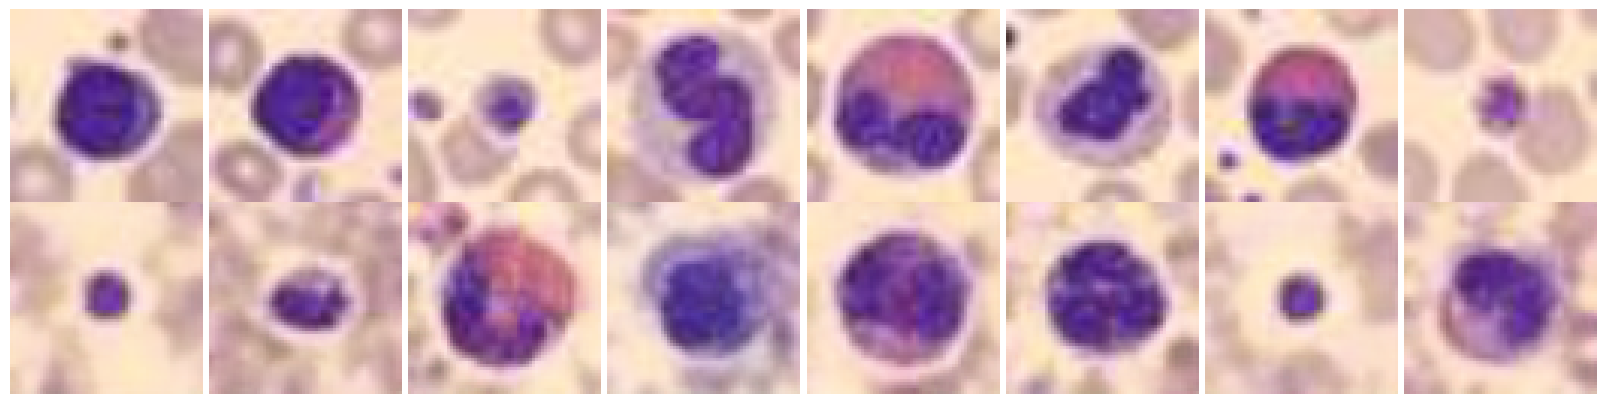

Epoch 1/40 — FID: 93.1134 | Val Gen Loss: 1.8292 | Val Disc Loss: 0.0822 Train Gen Loss: 2.0078 | Train Disc Loss: 0.0043


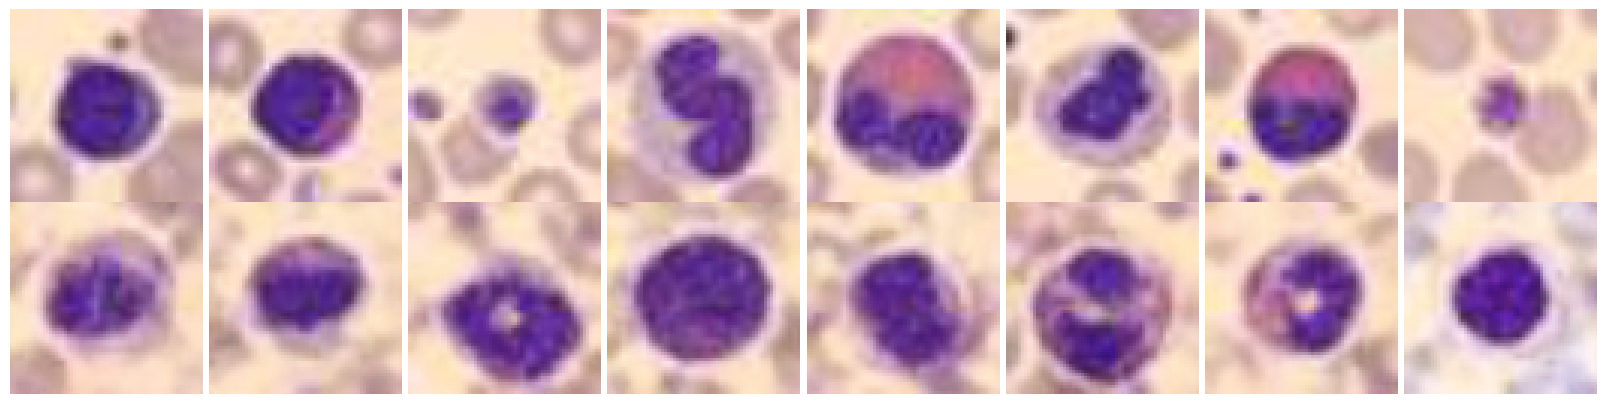

Epoch 2/40 — FID: 89.4985 | Val Gen Loss: 1.8791 | Val Disc Loss: 0.0662 Train Gen Loss: 2.0031 | Train Disc Loss: 0.0041


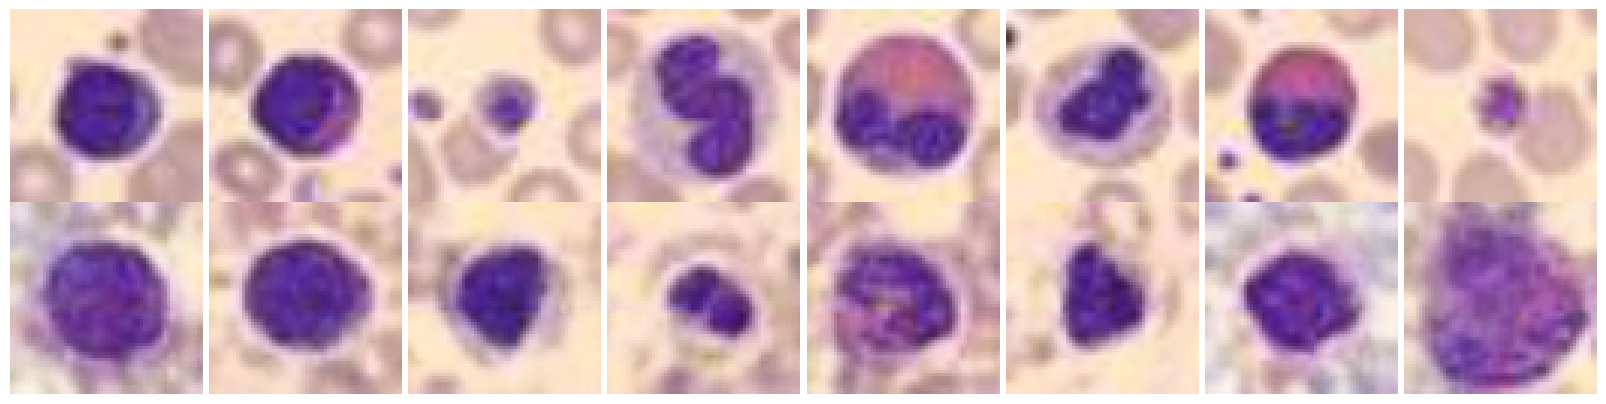

Epoch 3/40 — FID: 93.0732 | Val Gen Loss: 2.0221 | Val Disc Loss: 0.1562 Train Gen Loss: 2.0015 | Train Disc Loss: 0.0038


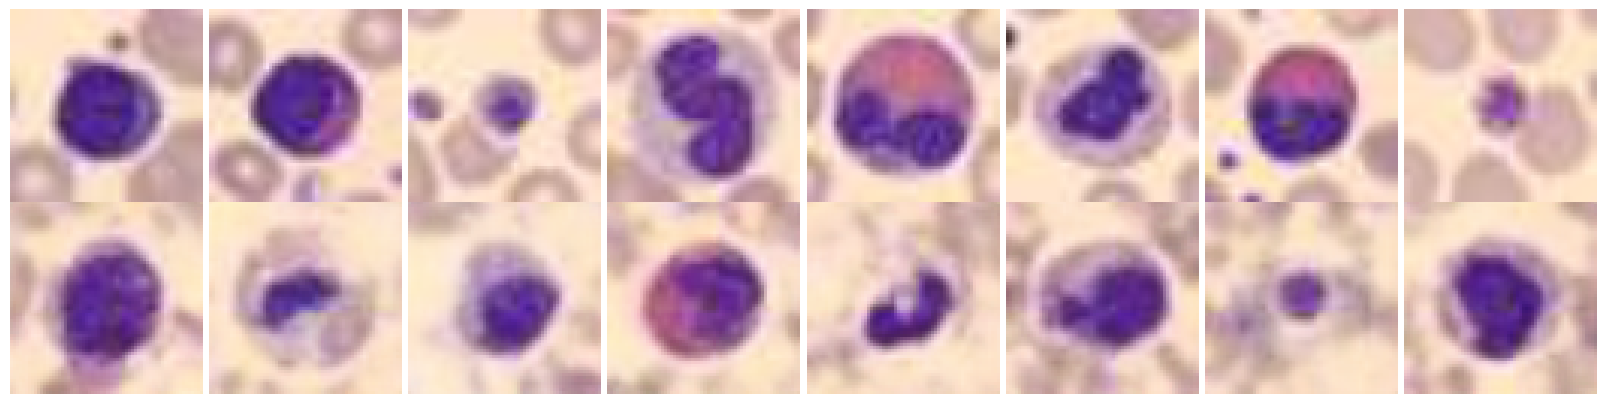

Epoch 4/40 — FID: 93.5729 | Val Gen Loss: 1.9149 | Val Disc Loss: 0.0799 Train Gen Loss: 2.0041 | Train Disc Loss: 0.0037


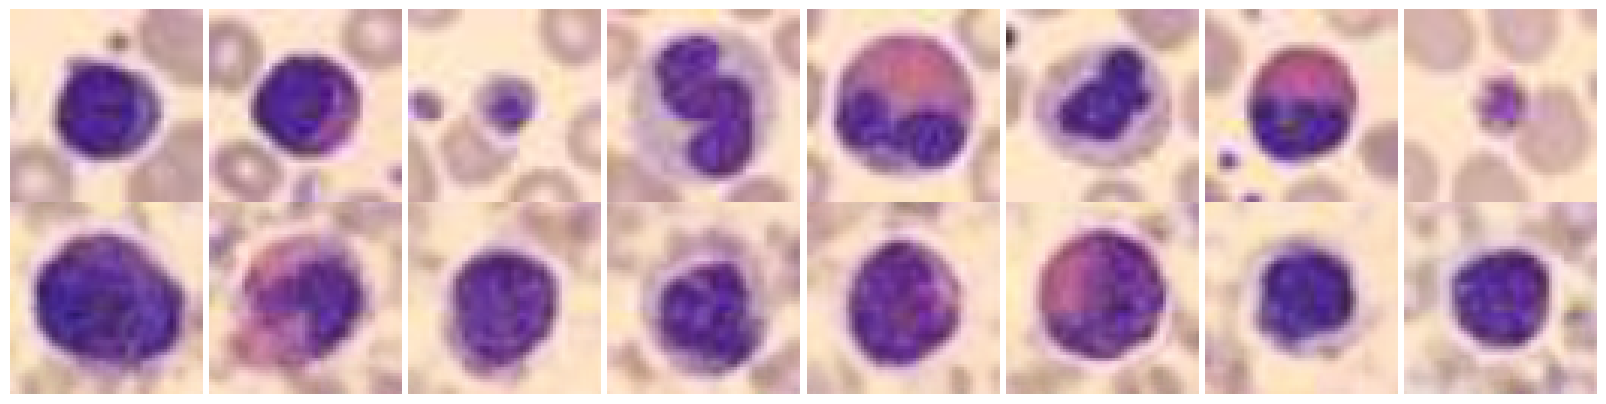

Epoch 5/40 — FID: 92.3299 | Val Gen Loss: 1.8904 | Val Disc Loss: 0.0860 Train Gen Loss: 2.0042 | Train Disc Loss: 0.0040


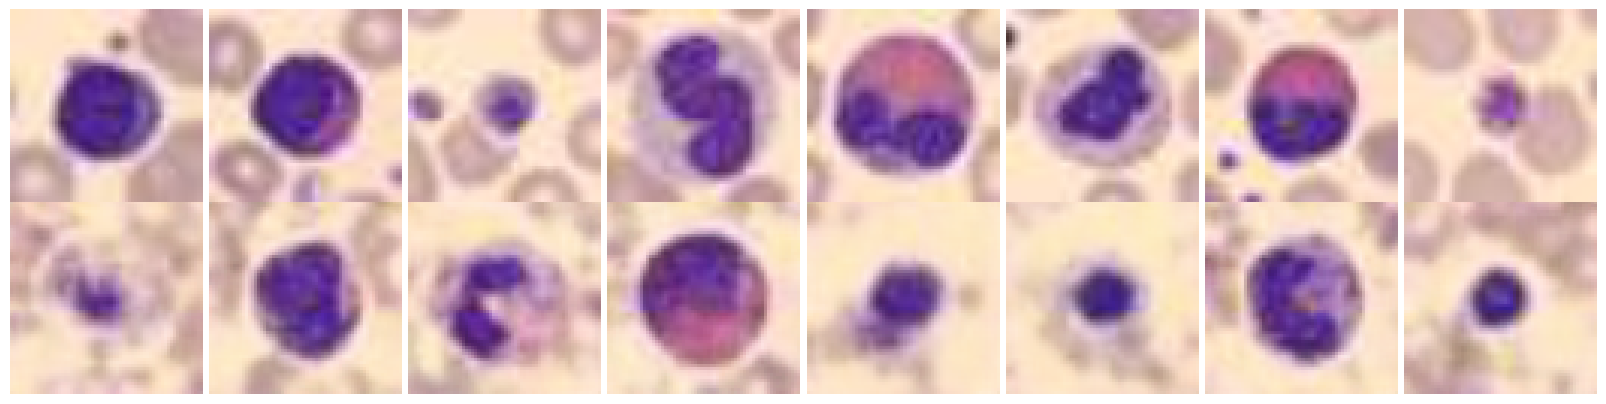

Epoch 6/40 — FID: 91.2342 | Val Gen Loss: 1.8929 | Val Disc Loss: 0.0987 Train Gen Loss: 2.0048 | Train Disc Loss: 0.0036


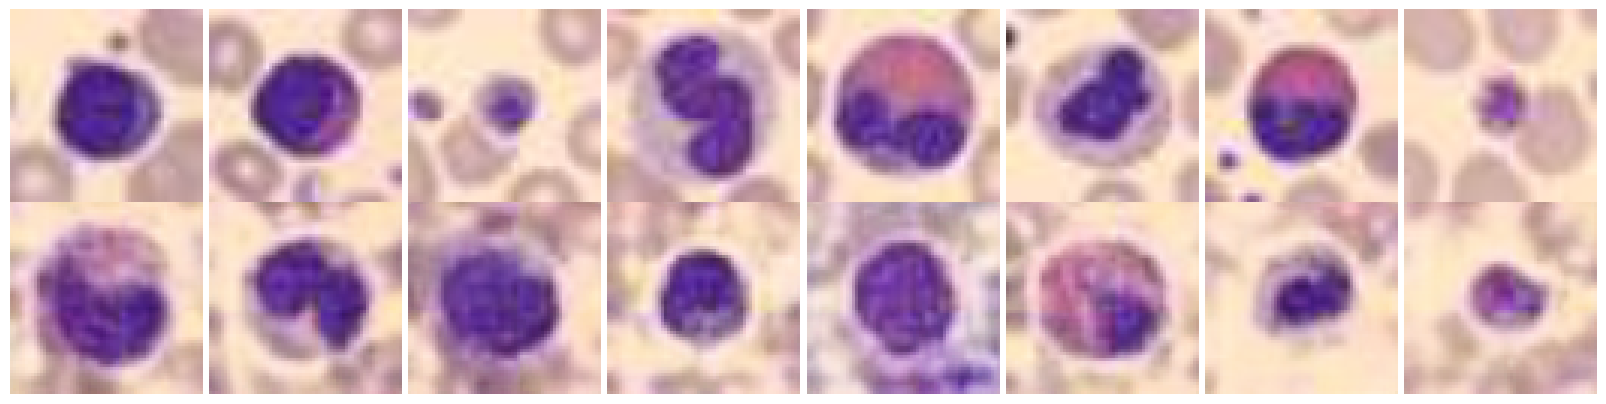

Epoch 7/40 — FID: 107.0492 | Val Gen Loss: 1.9722 | Val Disc Loss: 0.1104 Train Gen Loss: 2.0031 | Train Disc Loss: 0.0049


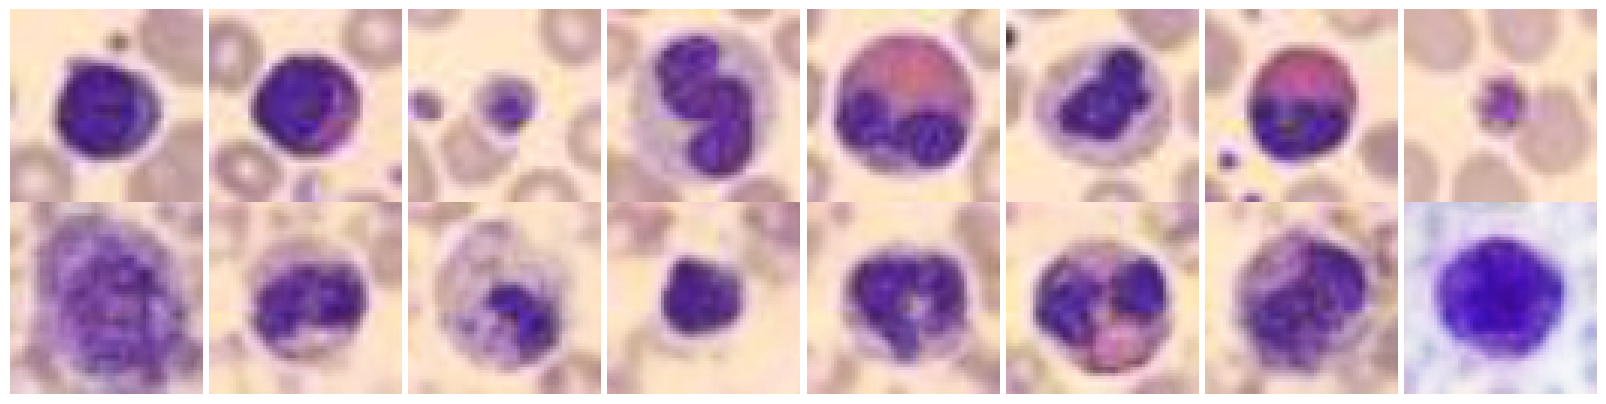

Epoch 8/40 — FID: 90.6775 | Val Gen Loss: 1.8397 | Val Disc Loss: 0.0685 Train Gen Loss: 2.0169 | Train Disc Loss: 0.0046


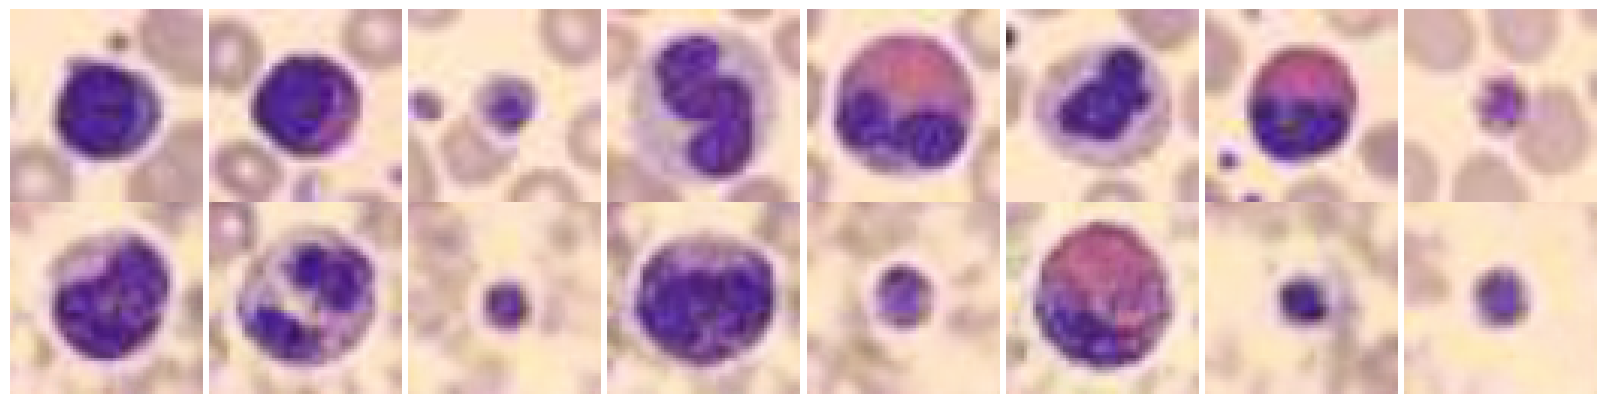

Epoch 9/40 — FID: 94.3932 | Val Gen Loss: 1.9421 | Val Disc Loss: 0.0796 Train Gen Loss: 2.0153 | Train Disc Loss: 0.0037


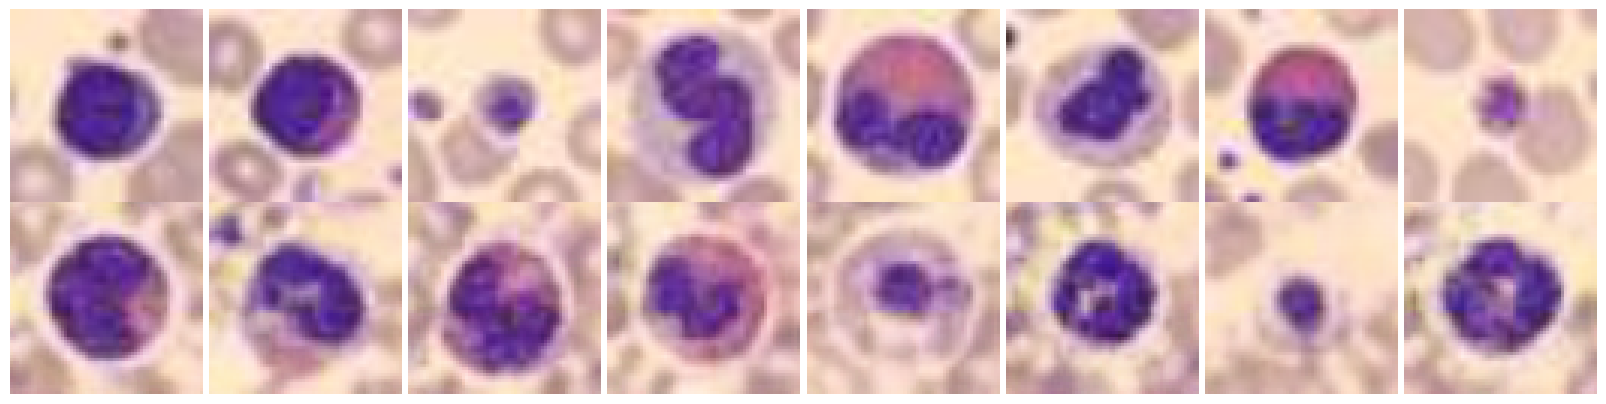

Epoch 10/40 — FID: 91.1600 | Val Gen Loss: 1.8755 | Val Disc Loss: 0.0808 Train Gen Loss: 2.0074 | Train Disc Loss: 0.0035


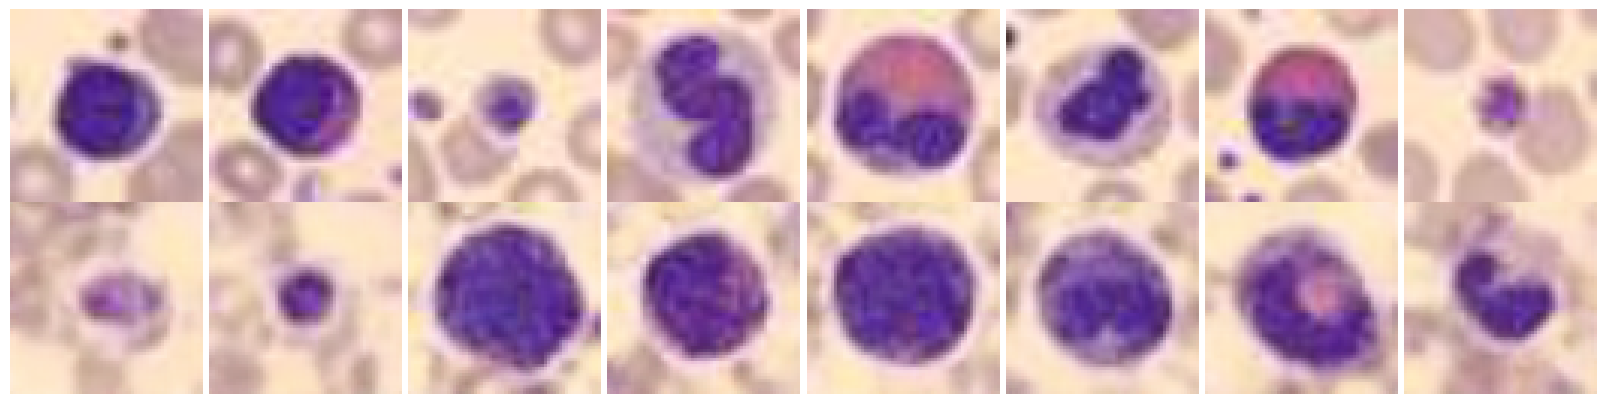

Epoch 11/40 — FID: 90.8862 | Val Gen Loss: 1.8566 | Val Disc Loss: 0.0596 Train Gen Loss: 2.0097 | Train Disc Loss: 0.0055


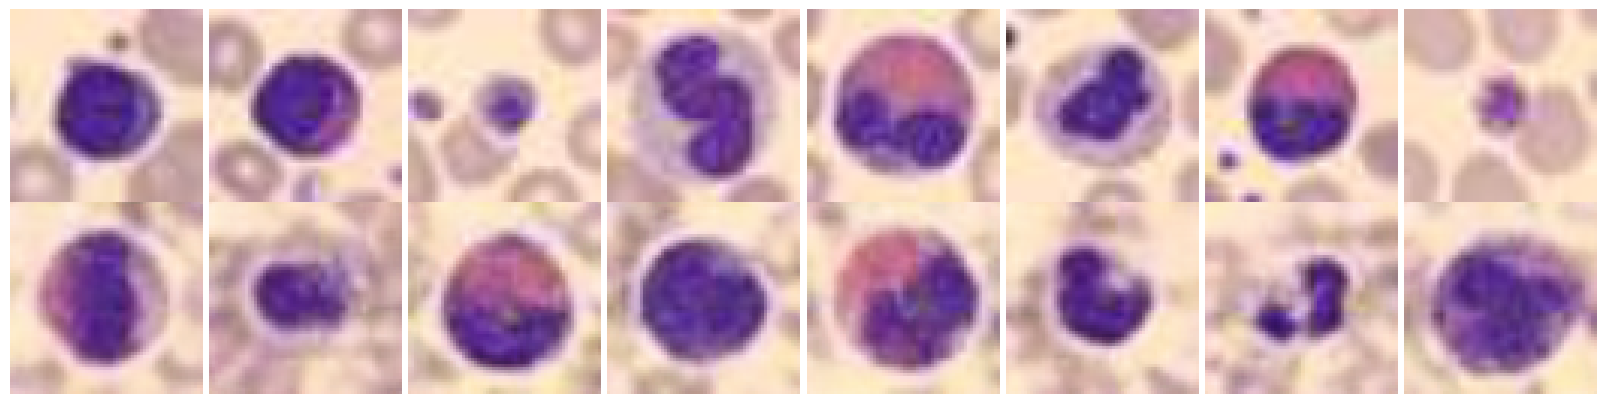

Epoch 12/40 — FID: 88.4178 | Val Gen Loss: 1.8313 | Val Disc Loss: 0.0723 Train Gen Loss: 2.0062 | Train Disc Loss: 0.0036


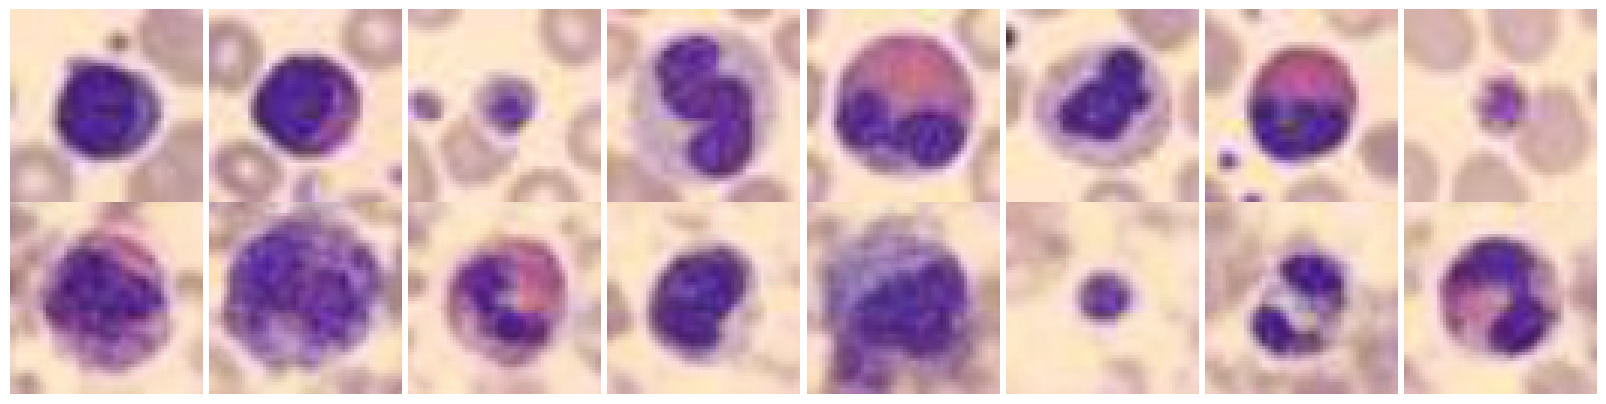

Epoch 13/40 — FID: 91.5432 | Val Gen Loss: 1.9720 | Val Disc Loss: 0.1448 Train Gen Loss: 2.0080 | Train Disc Loss: 0.0052


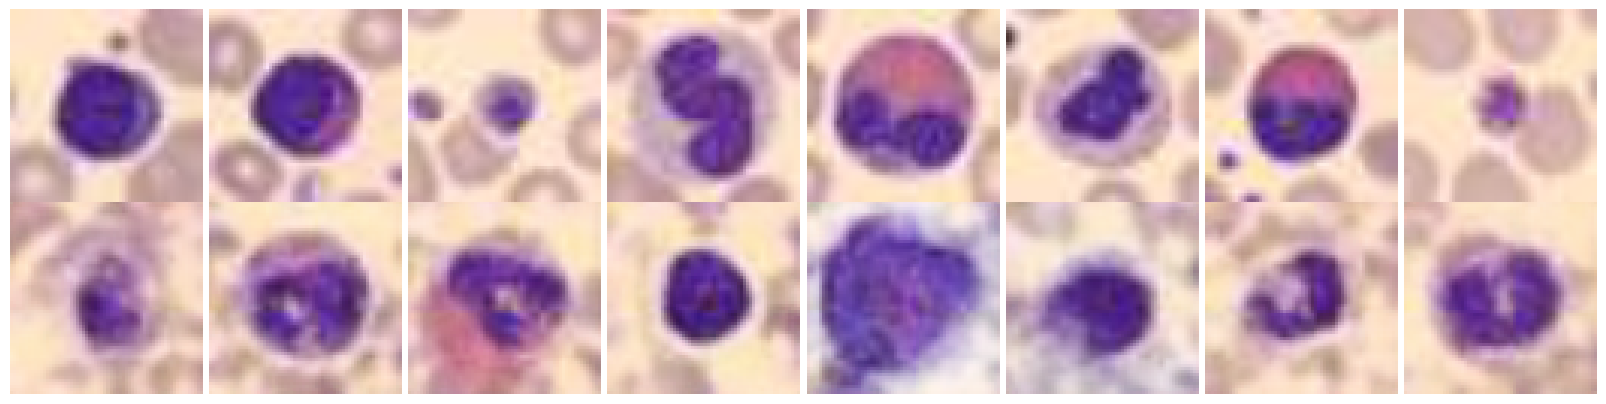

Epoch 14/40 — FID: 93.9894 | Val Gen Loss: 1.8468 | Val Disc Loss: 0.0751 Train Gen Loss: 2.0047 | Train Disc Loss: 0.0035


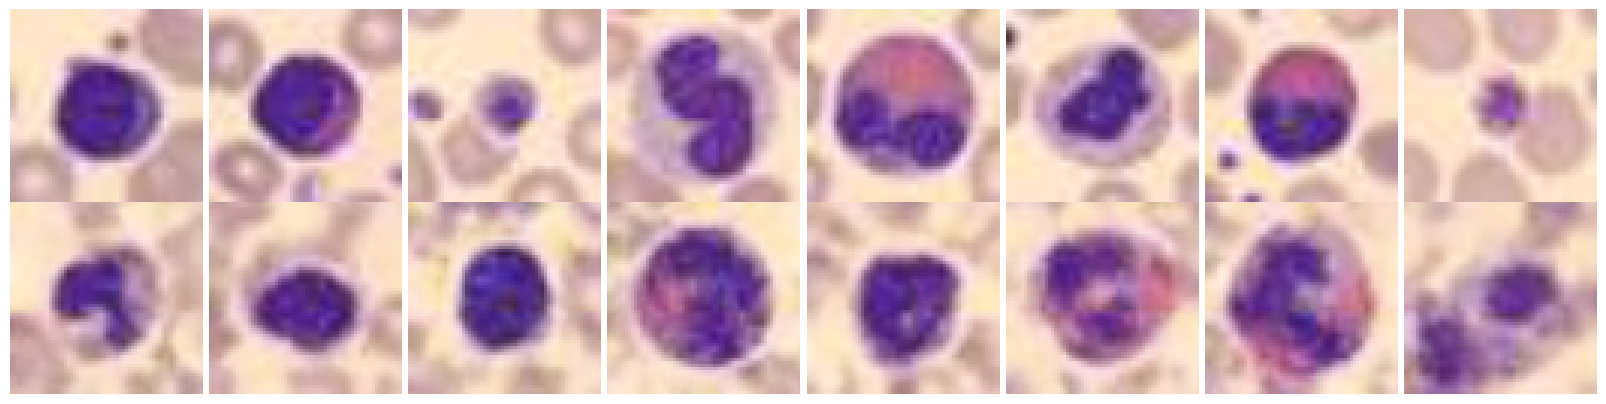

Epoch 15/40 — FID: 89.0454 | Val Gen Loss: 1.9003 | Val Disc Loss: 0.0999 Train Gen Loss: 1.9991 | Train Disc Loss: 0.0035


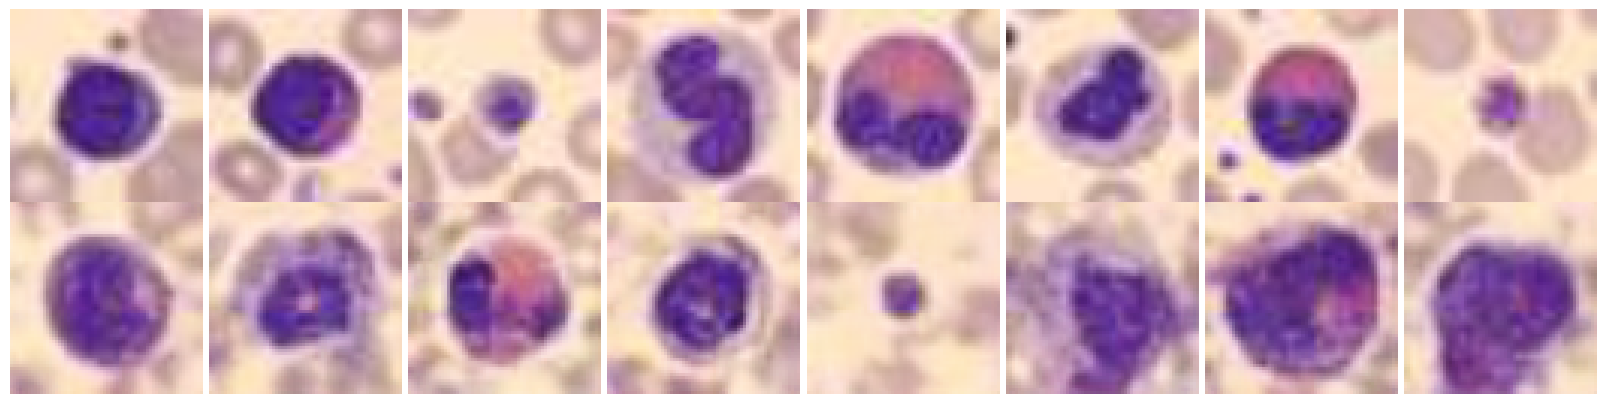

Epoch 16/40 — FID: 86.4137 | Val Gen Loss: 2.0210 | Val Disc Loss: 0.1362 Train Gen Loss: 2.0044 | Train Disc Loss: 0.0044


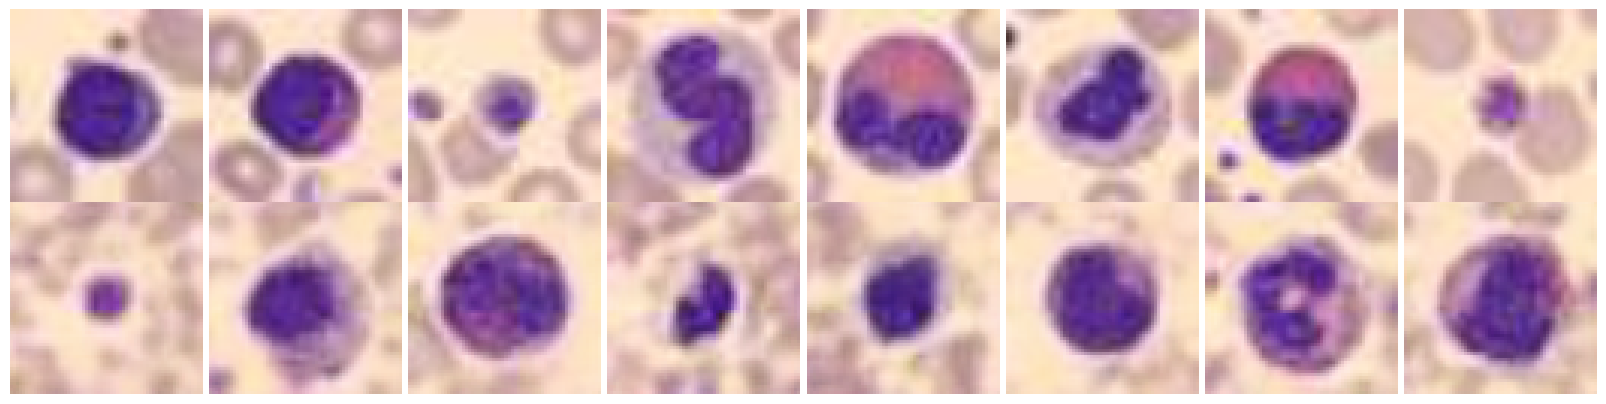

Epoch 17/40 — FID: 92.1947 | Val Gen Loss: 1.9013 | Val Disc Loss: 0.0868 Train Gen Loss: 1.9956 | Train Disc Loss: 0.0029


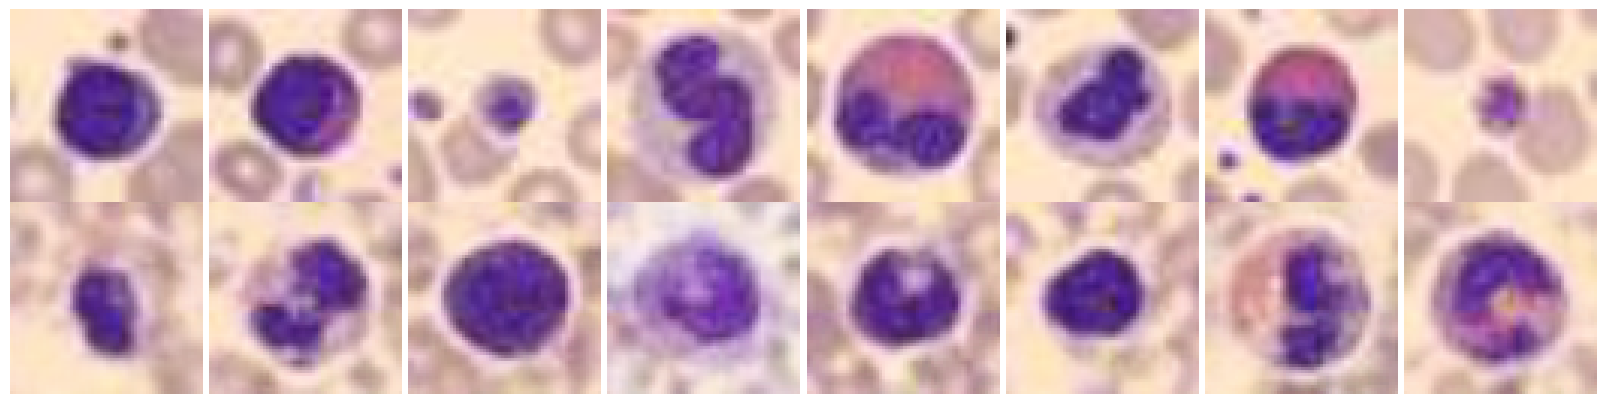

Epoch 18/40 — FID: 86.4591 | Val Gen Loss: 1.8597 | Val Disc Loss: 0.0808 Train Gen Loss: 2.0084 | Train Disc Loss: 0.0048


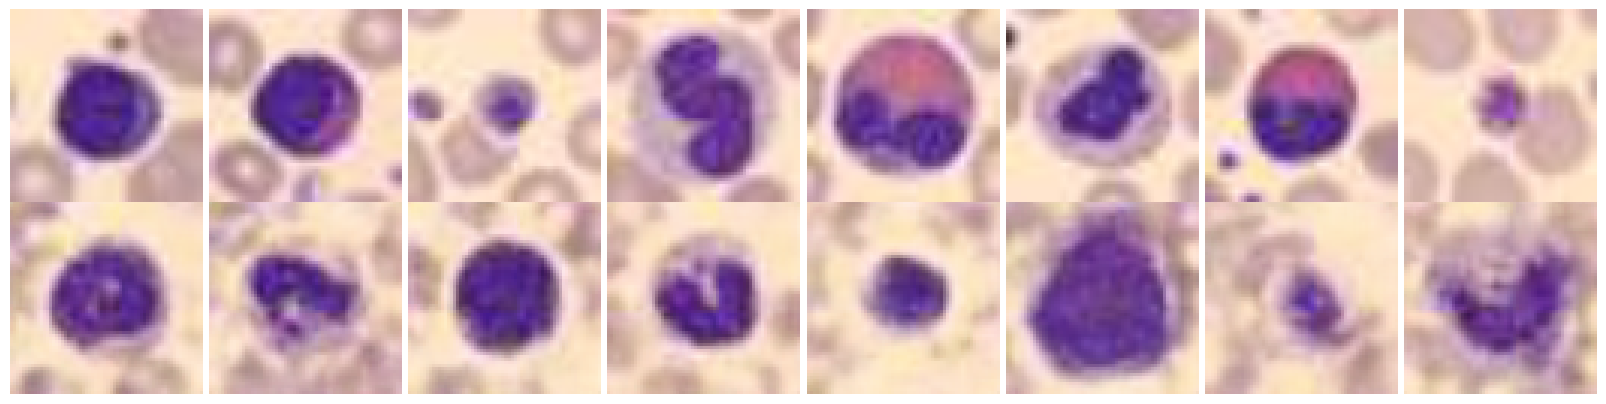

Epoch 19/40 — FID: 93.0688 | Val Gen Loss: 1.8867 | Val Disc Loss: 0.0839 Train Gen Loss: 1.9989 | Train Disc Loss: 0.0033


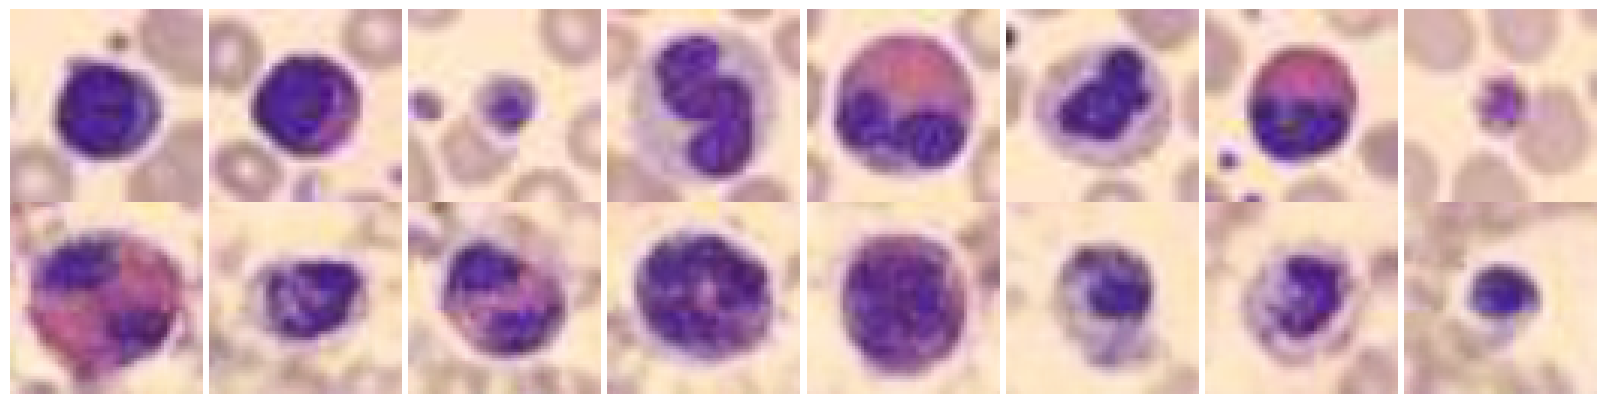

Epoch 20/40 — FID: 98.0110 | Val Gen Loss: 1.9769 | Val Disc Loss: 0.1035 Train Gen Loss: 2.0044 | Train Disc Loss: 0.0035


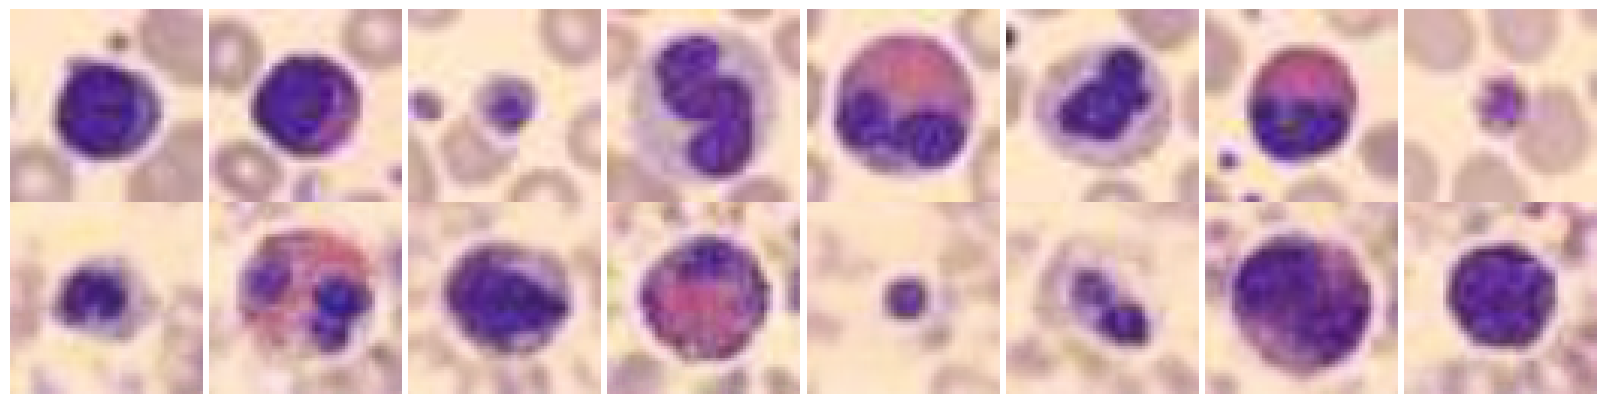

Epoch 21/40 — FID: 99.8671 | Val Gen Loss: 1.8442 | Val Disc Loss: 0.0692 Train Gen Loss: 2.0167 | Train Disc Loss: 0.0053


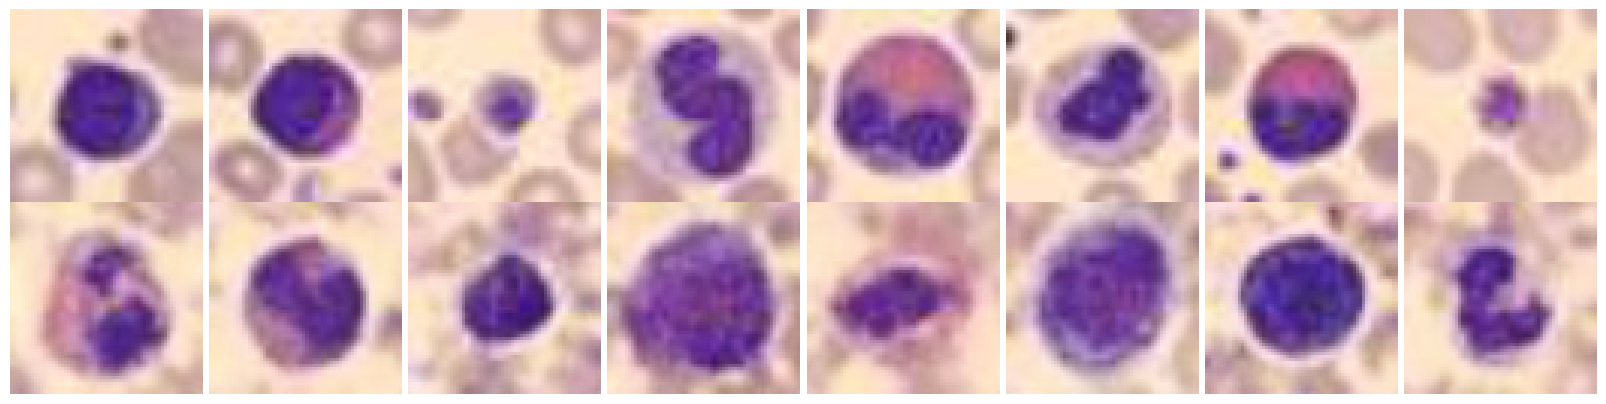

Epoch 22/40 — FID: 90.5145 | Val Gen Loss: 1.7503 | Val Disc Loss: 0.0570 Train Gen Loss: 2.0130 | Train Disc Loss: 0.0034


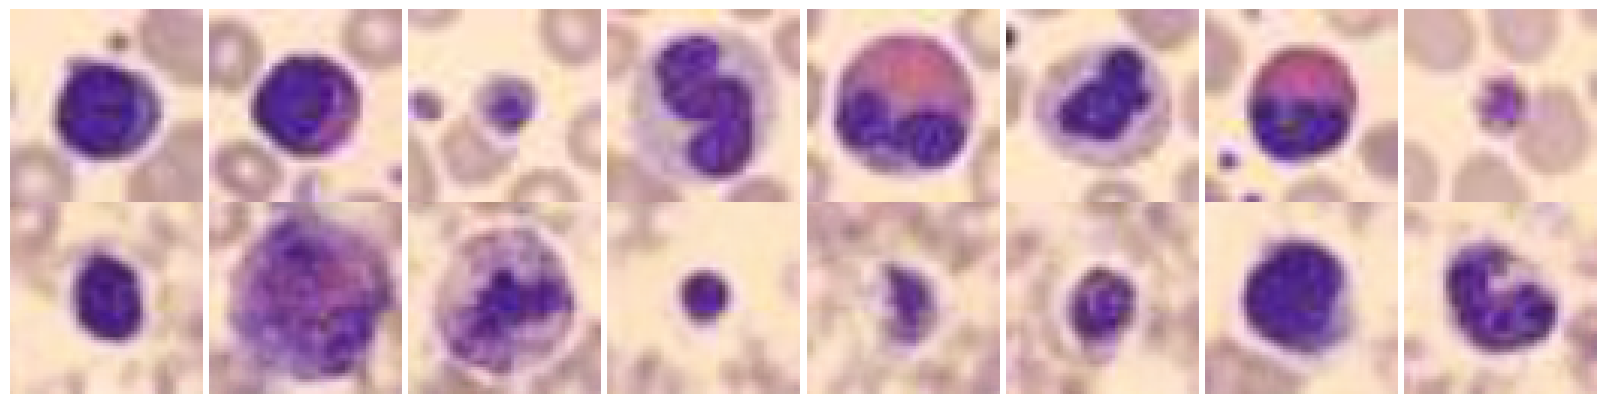

Epoch 23/40 — FID: 87.4084 | Val Gen Loss: 1.8372 | Val Disc Loss: 0.0403 Train Gen Loss: 2.0184 | Train Disc Loss: 0.0066


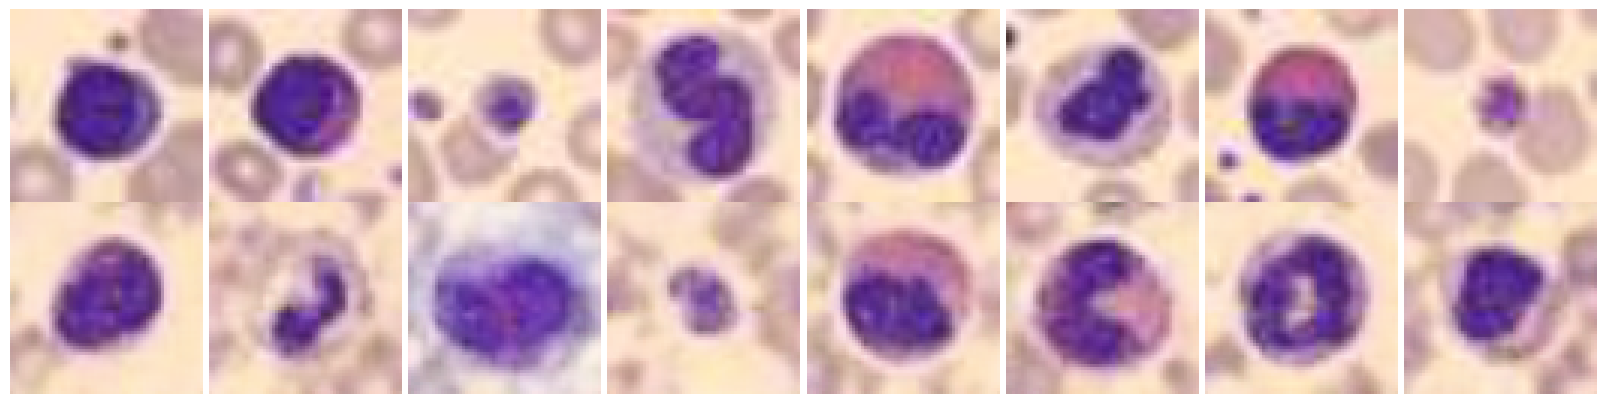

Epoch 24/40 — FID: 88.0060 | Val Gen Loss: 1.9832 | Val Disc Loss: 0.1394 Train Gen Loss: 2.0212 | Train Disc Loss: 0.0037


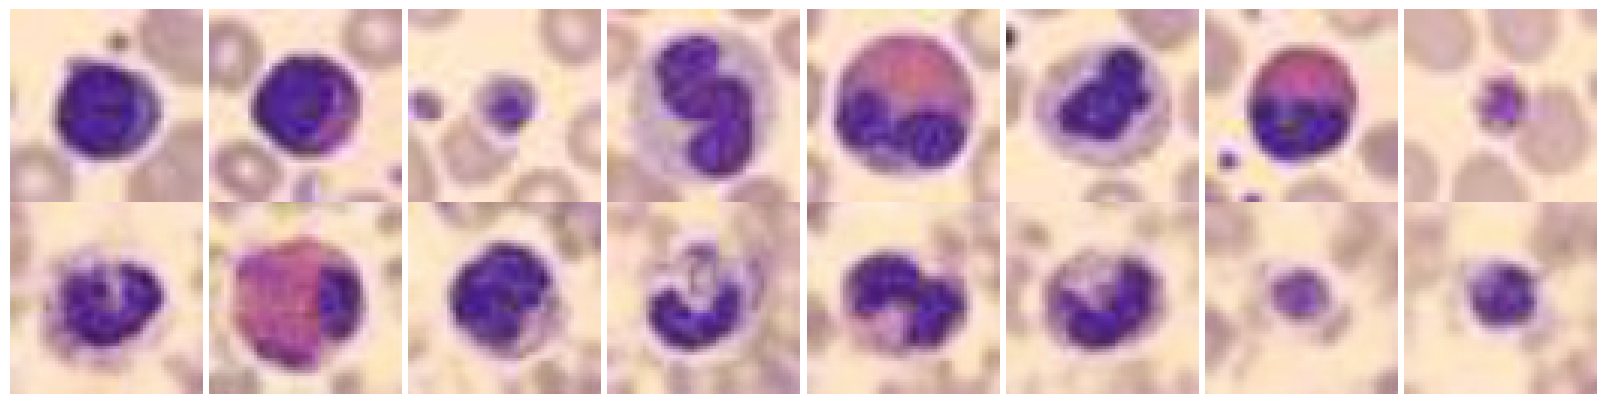

Epoch 25/40 — FID: 94.6698 | Val Gen Loss: 1.9814 | Val Disc Loss: 0.1082 Train Gen Loss: 2.0072 | Train Disc Loss: 0.0035


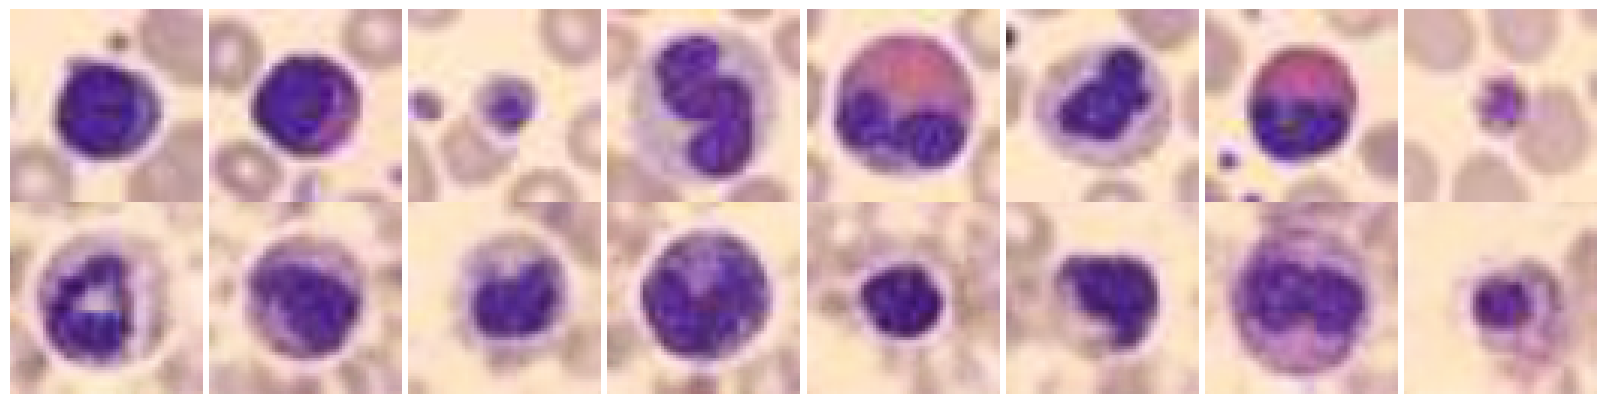

Epoch 26/40 — FID: 91.9233 | Val Gen Loss: 2.0266 | Val Disc Loss: 0.1899 Train Gen Loss: 2.0011 | Train Disc Loss: 0.0032


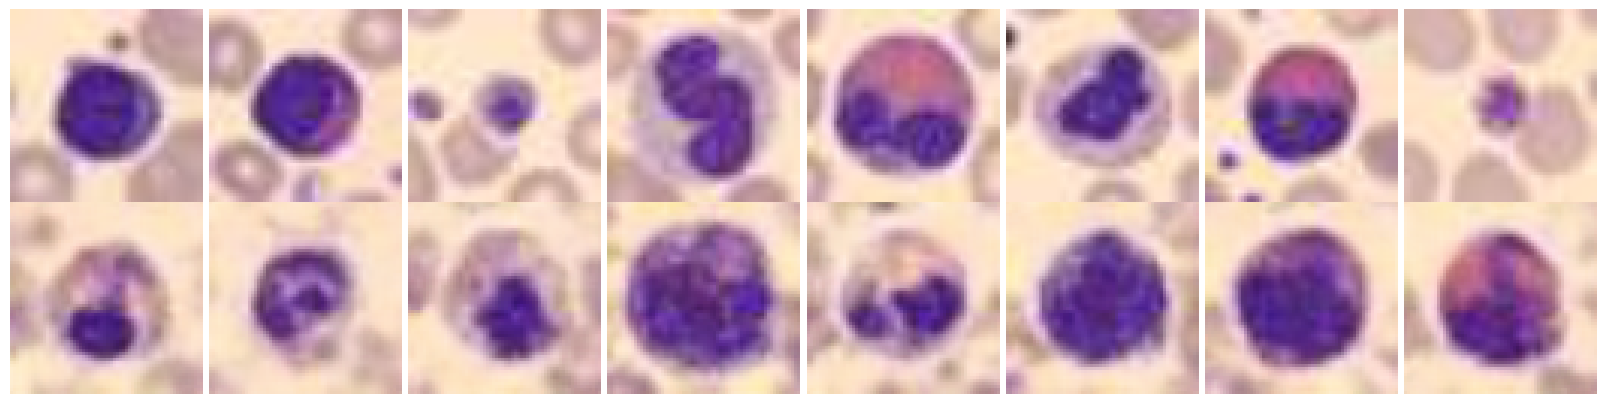

Epoch 27/40 — FID: 94.1028 | Val Gen Loss: 1.7741 | Val Disc Loss: 0.0474 Train Gen Loss: 2.0057 | Train Disc Loss: 0.0049


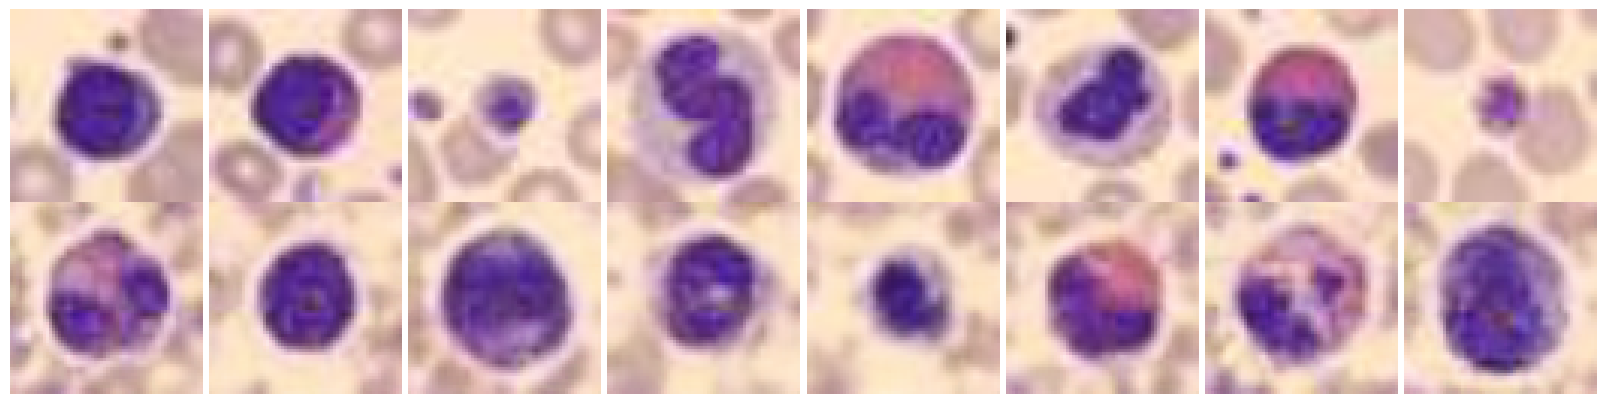

Epoch 28/40 — FID: 98.4341 | Val Gen Loss: 1.8487 | Val Disc Loss: 0.0908 Train Gen Loss: 2.0107 | Train Disc Loss: 0.0036


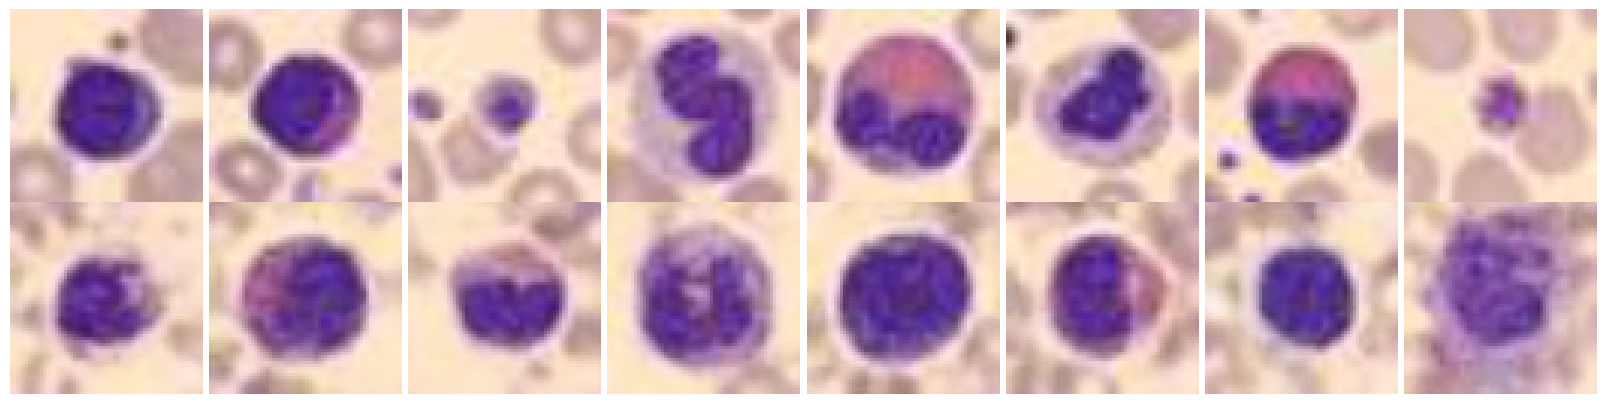

Epoch 29/40 — FID: 91.3487 | Val Gen Loss: 1.8541 | Val Disc Loss: 0.0899 Train Gen Loss: 2.0126 | Train Disc Loss: 0.0033


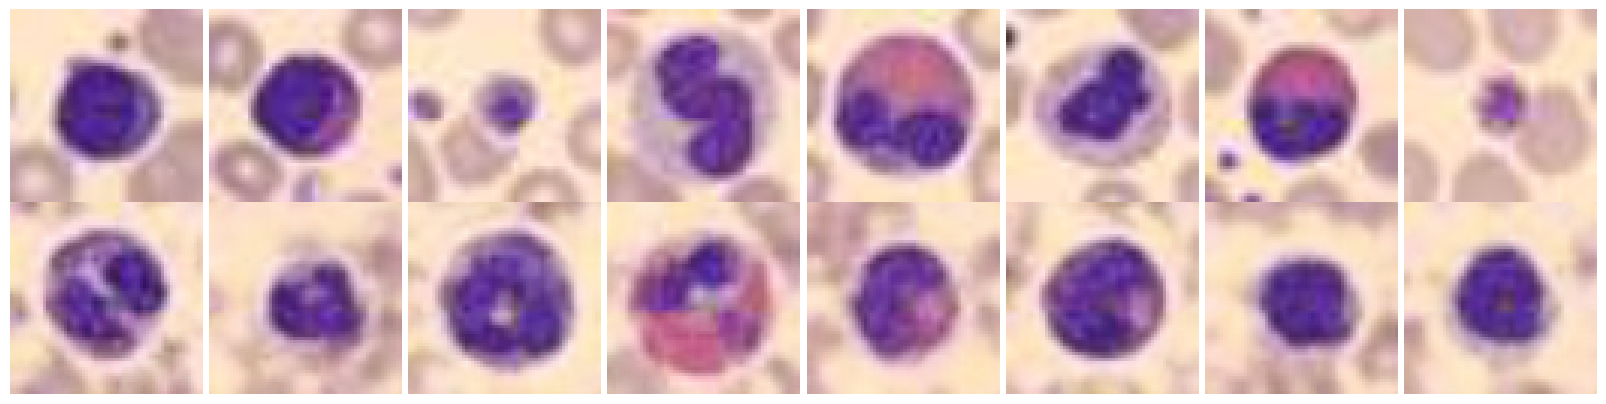

Epoch 30/40 — FID: 91.4824 | Val Gen Loss: 2.0451 | Val Disc Loss: 0.1978 Train Gen Loss: 2.0056 | Train Disc Loss: 0.0031


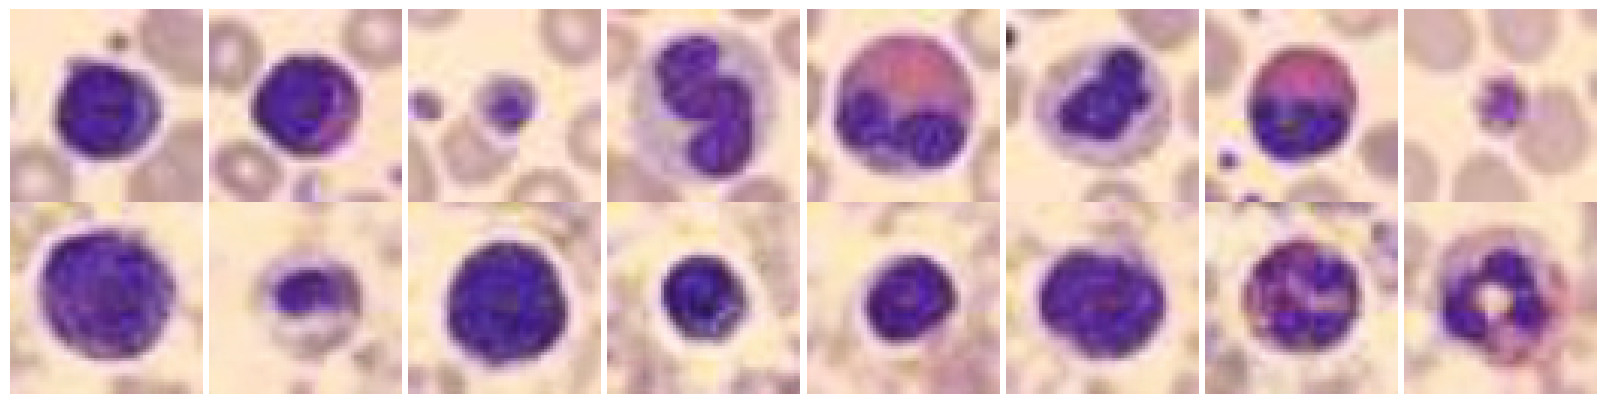

Epoch 31/40 — FID: 90.9949 | Val Gen Loss: 1.7873 | Val Disc Loss: 0.0660 Train Gen Loss: 2.0052 | Train Disc Loss: 0.0033


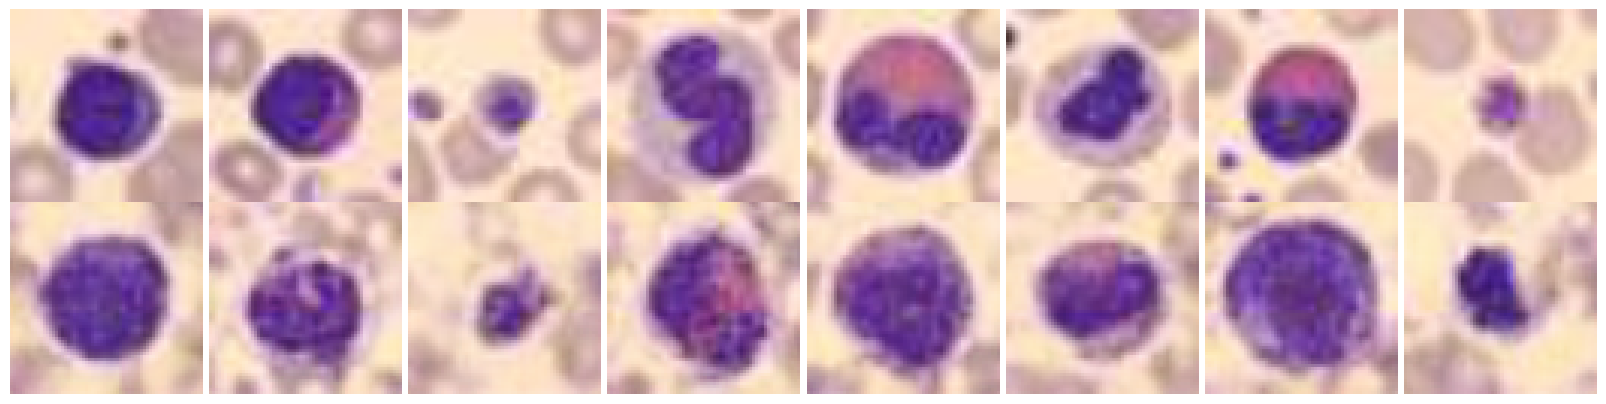

Epoch 32/40 — FID: 102.4048 | Val Gen Loss: 1.8894 | Val Disc Loss: 0.1084 Train Gen Loss: 2.0048 | Train Disc Loss: 0.0037


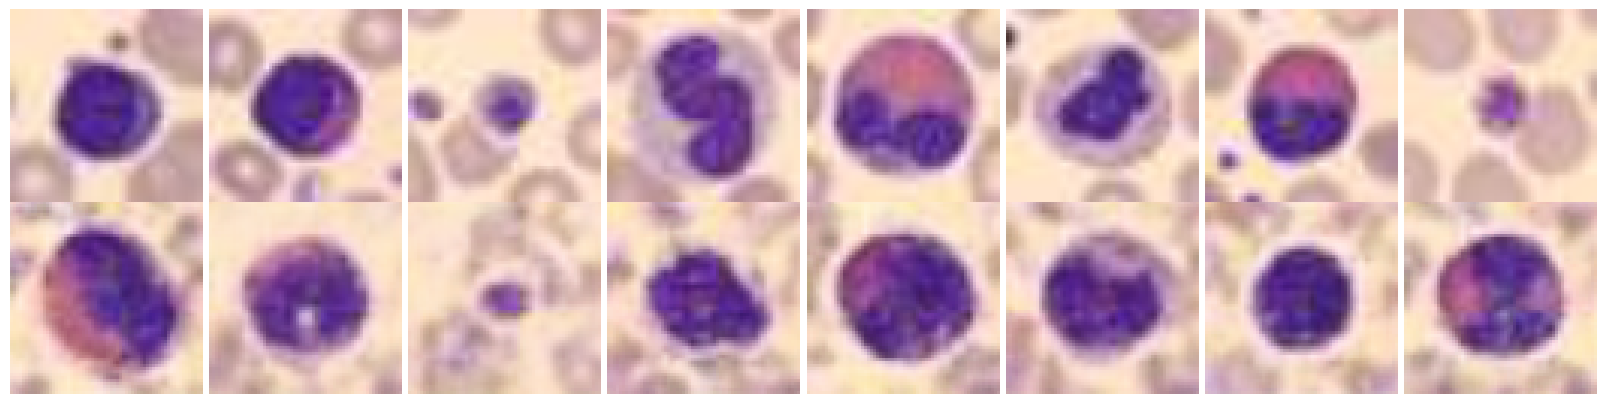

Epoch 33/40 — FID: 107.8982 | Val Gen Loss: 1.8899 | Val Disc Loss: 0.0980 Train Gen Loss: 2.0156 | Train Disc Loss: 0.0053


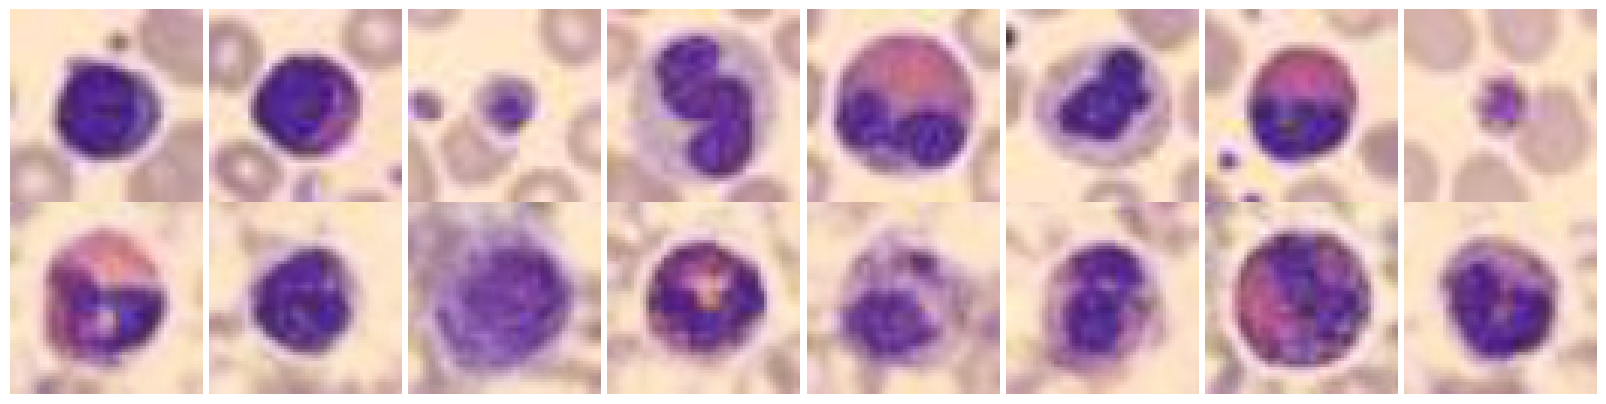

Epoch 34/40 — FID: 89.7351 | Val Gen Loss: 1.8305 | Val Disc Loss: 0.0799 Train Gen Loss: 2.0046 | Train Disc Loss: 0.0036


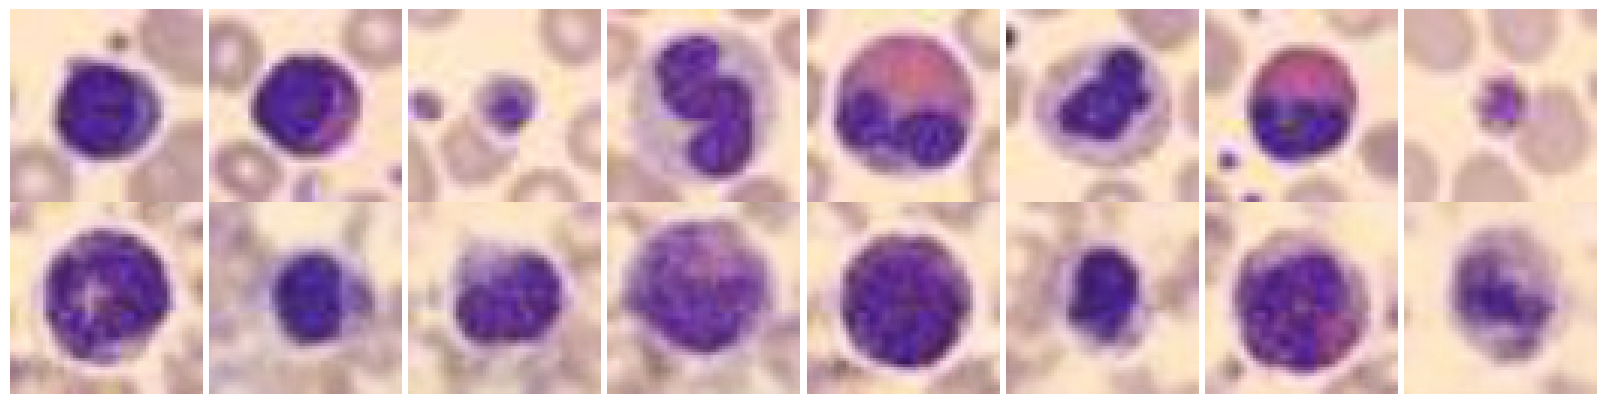

Epoch 35/40 — FID: 96.3488 | Val Gen Loss: 1.8971 | Val Disc Loss: 0.0753 Train Gen Loss: 2.0059 | Train Disc Loss: 0.0029


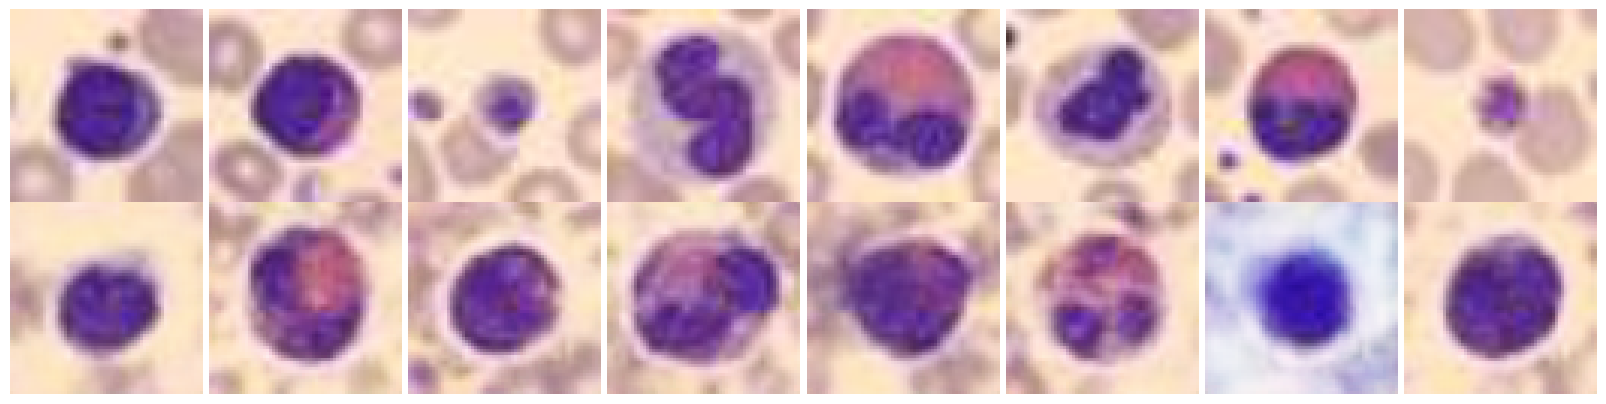

Epoch 36/40 — FID: 90.3438 | Val Gen Loss: 1.8145 | Val Disc Loss: 0.0717 Train Gen Loss: 2.0118 | Train Disc Loss: 0.0041


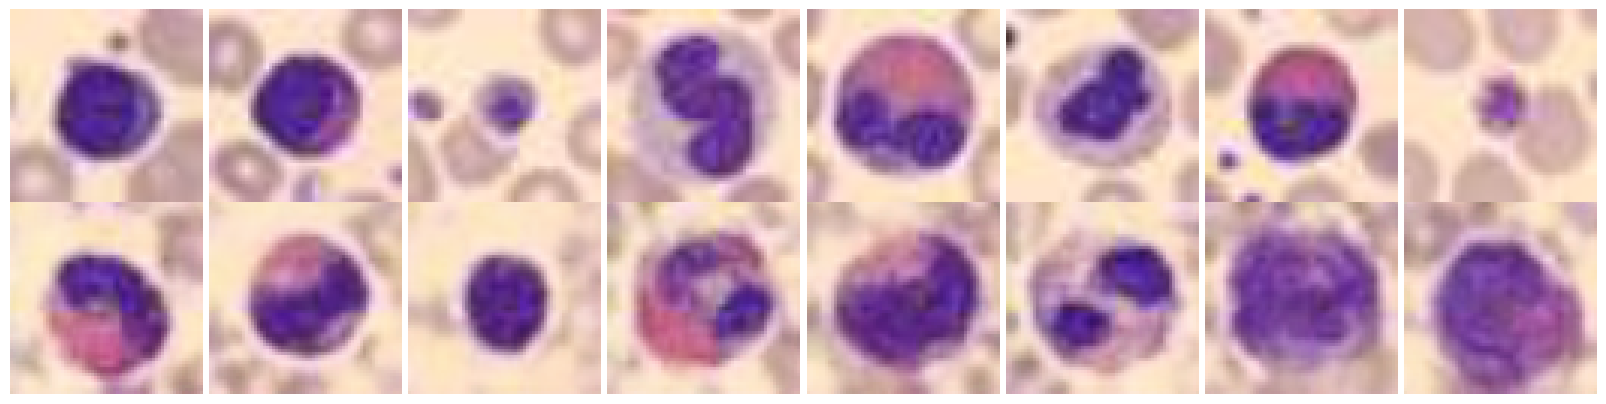

Epoch 37/40 — FID: 95.5968 | Val Gen Loss: 1.9323 | Val Disc Loss: 0.1006 Train Gen Loss: 2.0121 | Train Disc Loss: 0.0036


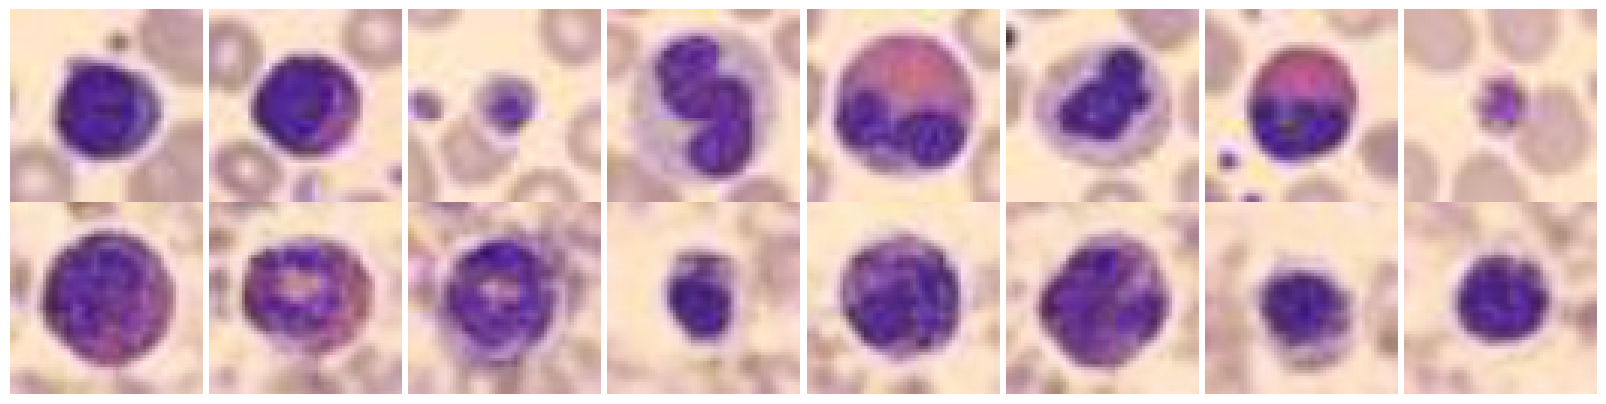

Epoch 38/40 — FID: 92.5054 | Val Gen Loss: 1.8354 | Val Disc Loss: 0.0926 Train Gen Loss: 2.0003 | Train Disc Loss: 0.0029


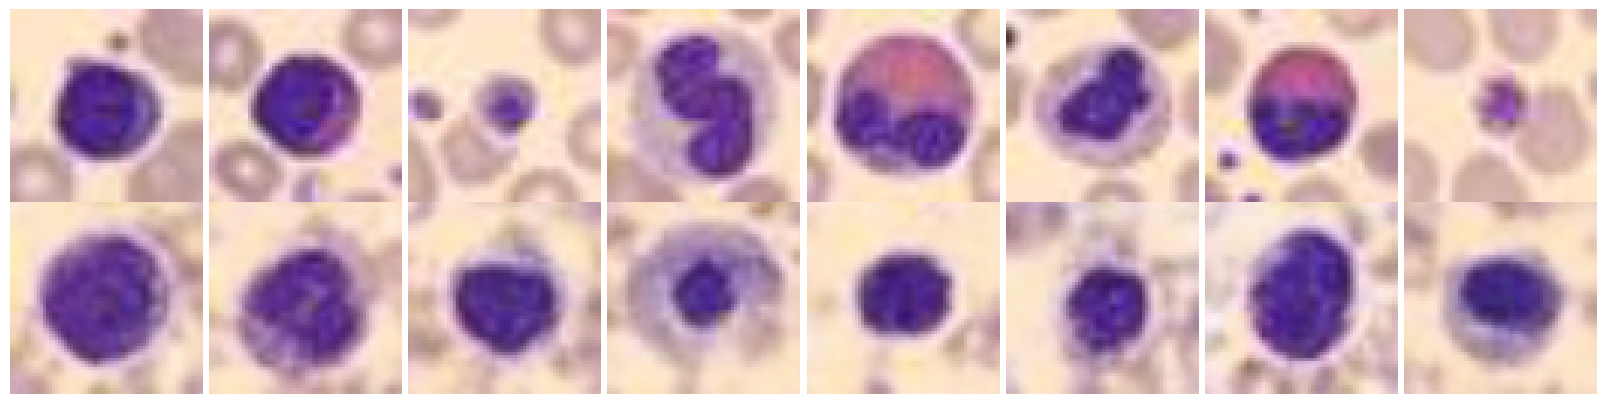

Epoch 39/40 — FID: 99.0490 | Val Gen Loss: 1.8991 | Val Disc Loss: 0.0805 Train Gen Loss: 2.0034 | Train Disc Loss: 0.0033


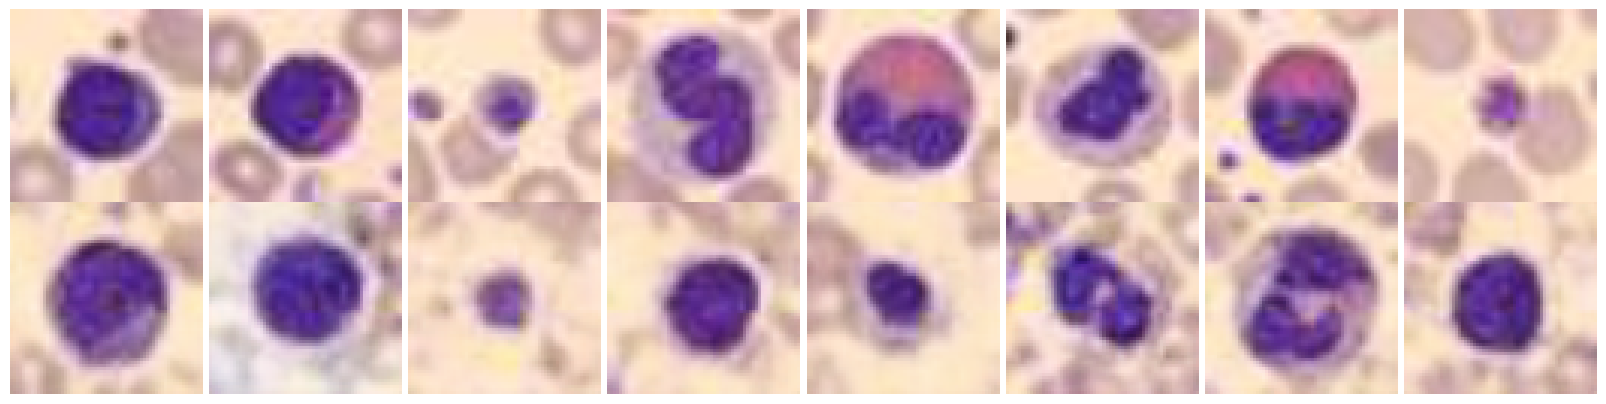

Epoch 40/40 — FID: 92.6638 | Val Gen Loss: 1.9762 | Val Disc Loss: 0.1321 Train Gen Loss: 2.0053 | Train Disc Loss: 0.0036


In [24]:
medmnist_train_eval_loop(
    generator=generator,
    discriminator=discriminator,
    gen_optimizer=gen_optimizer,
    disc_optimizer=discriminator_optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    adversarial_loss=adversarial_loss,
    lambda_l1=10.0,
    epochs=epochs,
    device=device,
    run=run,
)

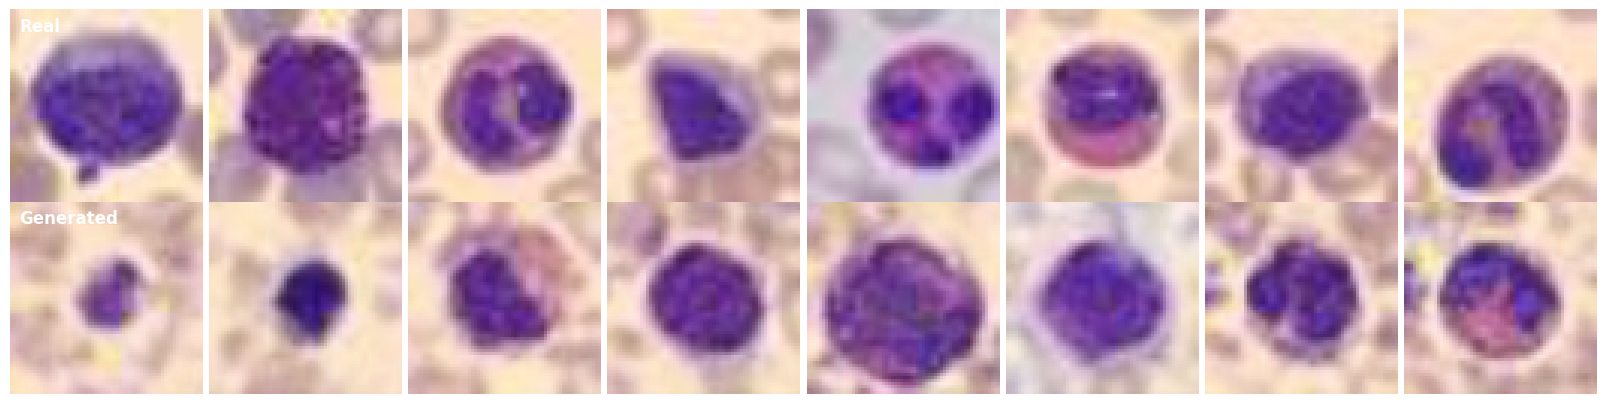


=== TEST RESULTS ===
Test Generator Loss: 1.9791
Test Discriminator Loss: 0.1326
Test FID: 91.5356
Test Time: 36.29s


In [42]:
medmnist_test(
    generator=generator,
    discriminator=discriminator,
    test_loader=test_loader,
    lambda_l1=10.0,
    device=device,
    run=run,
)

In [25]:
run.stop()

[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 8 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 8 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/sigk/optimizer-comparision/e/OP-11/metadata
